Read in the data from the data folder for both Qualifying and Race

In [4]:
import os 
data_raw_path = '../Formula1/data/data_raw'
dirs = [x for x in os.listdir(data_raw_path) if not x.startswith('.')]

for dirc in dirs:
    dir_raw_path = data_raw_path + '/' + dirc
    #os.filepaths


In [7]:
data_raw_path = '../Formula-1/data/data_raw'

file_paths = [dirpath+'/'+filename for dirpath, dirnames, filenames in os.walk(data_raw_path) for filename in filenames ]
for dirpath, dirnames, filenames in os.walk(data_raw_path):
    print(f"Current Folder: {dirpath}")
    print(f"Subdirectories: {dirnames}")
    print(f"Files: {filenames}")
    print("-" * 20)
print(file_paths)

[]


In [10]:
from pyspark.sql.functions import input_file_name, regexp_extract, col, first
from pyspark.sql import SparkSession
import shutil
import os

# 1. Initialize Spark Session
spark = (SparkSession
         .builder
         .appName('SparkDBApp')
         .getOrCreate())

# 2. Silence the noisy CSV schema mismatch warnings in your console logs
spark.sparkContext.setLogLevel("ERROR")

# 3. Create the database target if it does not exist
spark.sql("CREATE DATABASE IF NOT EXISTS formula1_EDA_race")

# Define the full array of CSV source targets
file_names = [
    'drivers', 'event', 'laps', 'race_control_messages',
    'results', 'session_info', 'session_status', 
    'track_status', 'weather_data'
]

# 4. Your robust file extraction function
def load_files(file_name):
    df = spark.read.csv(
        f"data/data_raw/*/session_*/{file_name}.csv",
        header=True,
        inferSchema=True
    )

    df = (
        df
        .withColumn('source_file', input_file_name())
        .withColumn(
            'year',
            regexp_extract(col('source_file'), r'data_raw/(\d{4})/', 1).cast('int')
        )
        .withColumn(
            'session_number',
            regexp_extract(col('source_file'), r'session_(\d+)', 1).cast('int')
        )
        .withColumn(
            'type_of_race',
            regexp_extract(col('source_file'), r'session_\d+_([^./]+)', 1).cast('string')
        )
    )

    # Safely drop '_c0' only if it exists in this specific table's schema
    if '_c0' in df.columns:
        df = df.drop('_c0')

    return df


# 5. Loop through every file name, load it, and save it dynamically
for name in file_names:
    print(f"Loading and processing data for: {name}...")
    
    try:
        # Load and process the files
        processed_df = load_files(name)
        
        # --- FIXED PIVOT LOGIC FOR THE EVENT TABLE ---
        if name == 'event':
            print("Detected event table. Pivoting key-value structure...")
            
            # 1. Reload the file without dropping '_c0' so we keep both columns
            raw_event_df = spark.read.csv(
                f"data/data_raw/*/session_*/{name}.csv",
                header=True,
                inferSchema=True
            )
            
            csv_cols = raw_event_df.columns
            if len(csv_cols) >= 2:
                # FIX: Extract strings from the list using indexing
                key_col = csv_cols[0]   # Extracts string (e.g., '_c0')
                val_col = csv_cols[1]   # Extracts string (e.g., '7')
                
                # 2. Re-apply your tracking metadata
                meta_df = (
                    raw_event_df
                    .withColumn('source_file', input_file_name())
                    .withColumn('year', regexp_extract(col('source_file'), r'data_raw/(\d{4})/', 1).cast('int'))
                    .withColumn('session_number', regexp_extract(col('source_file'), r'session_(\d+)', 1).cast('int'))
                    .withColumn('type_of_race', regexp_extract(col('source_file'), r'session_\d+_([^./]+)', 1).cast('string'))
                )
                
                meta_cols = ['source_file', 'year', 'session_number', 'type_of_race']
                
                # 3. Pivot the table using clear string references
                processed_df = (
                    meta_df
                    .groupBy(meta_cols)
                    .pivot(key_col) # Correctly receives a string parameter now
                    .agg(first(col(val_col)))
                    .select(
                        'source_file',
                        'year',
                        'session_number',
                        'type_of_race',
                        'RoundNumber',
                        'Location'
                    )
                )
            else:
                print(f"Warning: event table columns {csv_cols} don't match expected key-value layout.")
        # --------------------------------------------
        
        target_table = f"formula1_eda_race.{name}"
        
        # 1. Clear Spark metadata
        print(f"Dropping table if it exists: {target_table}...")
        spark.sql(f"DROP TABLE IF EXISTS {target_table}")
        
        # 2. Physically remove the existing folder location on disk
        target_path = f"/sfs/weka/scratch/aw2kc/Formula1/spark-warehouse/formula1_eda_race.db/{name}"
        if os.path.exists(target_path):
            print(f"Removing existing directory location: {target_path}...")
            shutil.rmtree(target_path)
        
        # 3. Write the fresh DataFrame as a brand-new table
        print(f"Saving to table: {target_table}...")
        processed_df.write.mode("overwrite").saveAsTable(target_table)
        print(f"Successfully saved to {target_table}!\n")
        
    except Exception as e:
        print(f"Error processing {name}: {e}\n")

print("All tables successfully processed and saved to formula1_eda!")


Loading and processing data for: drivers...
Dropping table if it exists: formula1_eda_race.drivers...
Removing existing directory location: /sfs/weka/scratch/aw2kc/Formula1/spark-warehouse/formula1_eda_race.db/drivers...
Saving to table: formula1_eda_race.drivers...


Successfully saved to formula1_eda_race.drivers!

Loading and processing data for: event...
Detected event table. Pivoting key-value structure...
Dropping table if it exists: formula1_eda_race.event...
Removing existing directory location: /sfs/weka/scratch/aw2kc/Formula1/spark-warehouse/formula1_eda_race.db/event...
Saving to table: formula1_eda_race.event...
Successfully saved to formula1_eda_race.event!

Loading and processing data for: laps...
Dropping table if it exists: formula1_eda_race.laps...
Removing existing directory location: /sfs/weka/scratch/aw2kc/Formula1/spark-warehouse/formula1_eda_race.db/laps...
Saving to table: formula1_eda_race.laps...


Successfully saved to formula1_eda_race.laps!

Loading and processing data for: race_control_messages...
Dropping table if it exists: formula1_eda_race.race_control_messages...
Removing existing directory location: /sfs/weka/scratch/aw2kc/Formula1/spark-warehouse/formula1_eda_race.db/race_control_messages...
Saving to table: formula1_eda_race.race_control_messages...
Successfully saved to formula1_eda_race.race_control_messages!

Loading and processing data for: results...
Dropping table if it exists: formula1_eda_race.results...
Removing existing directory location: /sfs/weka/scratch/aw2kc/Formula1/spark-warehouse/formula1_eda_race.db/results...
Saving to table: formula1_eda_race.results...
Successfully saved to formula1_eda_race.results!

Loading and processing data for: session_info...
Dropping table if it exists: formula1_eda_race.session_info...
Removing existing directory location: /sfs/weka/scratch/aw2kc/Formula1/spark-warehouse/formula1_eda_race.db/session_info...
Saving to tab

In [11]:
#Check if events table was pivoted
race_name = spark.sql('SELECT * FROM formula1_eda_race.event where type_of_race="R"')
race_name.show(5)

+--------------------+----+--------------+------------+-----------+-----------------+
|         source_file|year|session_number|type_of_race|RoundNumber|         Location|
+--------------------+----+--------------+------------+-----------+-----------------+
|file:///sfs/weka/...|2018|            10|           R|         10|      Silverstone|
|file:///sfs/weka/...|2018|            11|           R|         11|       Hockenheim|
|file:///sfs/weka/...|2018|            12|           R|         12|         Budapest|
|file:///sfs/weka/...|2018|            13|           R|         13|Spa-Francorchamps|
|file:///sfs/weka/...|2018|            14|           R|         14|            Monza|
+--------------------+----+--------------+------------+-----------+-----------------+
only showing top 5 rows


In [85]:
#confirm I can reach the tables
spark.sql('SELECT * FROM formula1_eda_race.drivers').show(5)

+---+--------------------+----+--------------+------------+
|  0|         source_file|year|session_number|type_of_race|
+---+--------------------+----+--------------+------------+
|  1|file:///sfs/weka/...|2022|             9|           R|
| 55|file:///sfs/weka/...|2022|             9|           R|
| 44|file:///sfs/weka/...|2022|             9|           R|
| 63|file:///sfs/weka/...|2022|             9|           R|
| 16|file:///sfs/weka/...|2022|             9|           R|
+---+--------------------+----+--------------+------------+
only showing top 5 rows


Now we will investigate the race data to determine which predictors we would like to keep for the model.

Step 1. Create a master results dataframe that contains weather data, race control messages, and average lap time.

In [12]:
# We want to add onto results the average air temp,
# humidity, pressure, rainfall, tracktemp, wind direction, and wind speed

weather_averages = spark.sql("""
    SELECT 
        session_number, year,
        AVG(AirTemp) AS avg_air_temp, 
        AVG(Humidity) AS avg_humidity, 
        AVG(Pressure) AS avg_pressure, 
        MAX(Rainfall) AS rain, 
        AVG(TrackTemp) AS avg_track_temp, 
        AVG(WindDirection) AS avg_wind_direction, 
        AVG(WindSpeed) AS avg_wind_speed 
    FROM formula1_eda_race.weather_data
    where type_of_race = "R"
    GROUP BY session_number, year
""")

weather_averages.show(5)

+--------------+----+------------------+------------------+------------------+-----+------------------+------------------+------------------+
|session_number|year|      avg_air_temp|      avg_humidity|      avg_pressure| rain|    avg_track_temp|avg_wind_direction|    avg_wind_speed|
+--------------+----+------------------+------------------+------------------+-----+------------------+------------------+------------------+
|            11|2023| 28.80853658536585| 32.80487804878049| 988.4018292682914|false| 48.57926829268294|174.53658536585365|1.4408536585365836|
|            22|2023| 26.96282051282048|              51.0|1014.9275641025635|false| 33.46089743589744|284.93589743589746|1.7948717948717932|
|             8|2024|21.596500000000006|             63.99|1018.7434999999994|false|46.317999999999984|           160.895|            0.9795|
|            11|2021| 27.22670157068063| 68.61570680628276| 977.6308900523562| true| 37.82251308900524|104.59162303664921|0.5675392670157061|
|     

In [9]:
# Bring in race control information
spark.sql('SELECT * FROM formula1_eda_race.race_control_messages').show(5)

+-------------------+--------+--------------------+------+-------------+------+------+------------+---+--------------------+----+--------------+------------+
|               Time|Category|             Message|Status|         Flag| Scope|Sector|RacingNumber|Lap|         source_file|year|session_number|type_of_race|
+-------------------+--------+--------------------+------+-------------+------+------+------------+---+--------------------+----+--------------+------------+
|2023-05-28 12:05:10|   Other|PINK HEAD PADDING...|  NULL|         NULL|  NULL|  NULL|        NULL|1.0|file:///sfs/weka/...|2023|             6|           R|
|2023-05-28 12:07:39|    Flag|DOUBLE YELLOW IN ...|  NULL|DOUBLE YELLOW|Sector|   9.0|        NULL|1.0|file:///sfs/weka/...|2023|             6|           R|
|2023-05-28 12:07:53|    Flag|CLEAR IN TRACK SE...|  NULL|        CLEAR|Sector|   9.0|        NULL|1.0|file:///sfs/weka/...|2023|             6|           R|
|2023-05-28 12:10:00|    Flag|GREEN LIGHT - PIT...| 

In [13]:
# Create a dataframe that details the number of flags each race
flag_counts = spark.sql("""
    SELECT 
        year,
        session_number AS session,
        COUNT(CASE WHEN Flag IS NOT NULL AND Flag != 'CLEAR' THEN 1 END) AS active_flag_count
    FROM formula1_eda_race.race_control_messages 
    where 
    GROUP BY year, session_number
""")

flag_counts.show(5)

+----+-------+-----------------+
|year|session|active_flag_count|
+----+-------+-----------------+
|2024|     21|               24|
|2021|     17|               58|
|2021|     19|               82|
|2024|      7|               75|
|2023|     17|               31|
+----+-------+-----------------+
only showing top 5 rows


In [14]:
# Bring in average lap time
# Extract the parts using substring positions and convert to total seconds
driver_lap_temps = spark.sql("""
    SELECT 
        DriverNumber,
        year,
        session_number,
        -- '0 days 00:01:22.8'
        -- Substring positions: Hours=8(2 chars), Minutes=11(2 chars), Seconds=14(remaining)
        avg(CAST(substring(LapTime, 8, 2) AS DOUBLE) * 3600 +
        CAST(substring(LapTime, 11, 2) AS DOUBLE) * 60 +
        CAST(substring(LapTime, 14, 9) AS DOUBLE)) AS avg_lap_time_seconds
    FROM formula1_eda_race.laps
    WHERE LapTime IS NOT NULL
    group by DriverNumber, year, session_number
""")

driver_lap_temps.show(5)


+------------+----+--------------+--------------------+
|DriverNumber|year|session_number|avg_lap_time_seconds|
+------------+----+--------------+--------------------+
|          27|2025|            15|   82.35519444444444|
|          44|2022|            11|    71.9088591549296|
|           4|2022|            20|   85.08175714285716|
|          23|2020|             3|   83.58269999999999|
|           5|2025|            15|            82.38075|
+------------+----+--------------+--------------------+
only showing top 5 rows


In [17]:
# Create a dataframe for race results
results = spark.sql('SELECT * FROM formula1_eda_race.results where type_of_race = "R"')
results.show(5)

+------------+-------------+------------+--------------+---------------+---------+--------+---------+----------+---------------+--------------------+-----------+--------+------------------+------------+----+----+----+--------------------+--------+------+----+--------------------+----+--------------+------------+
|DriverNumber|BroadcastName|Abbreviation|      DriverId|       TeamName|TeamColor|  TeamId|FirstName|  LastName|       FullName|         HeadshotUrl|CountryCode|Position|ClassifiedPosition|GridPosition|  Q1|  Q2|  Q3|                Time|  Status|Points|Laps|         source_file|year|session_number|type_of_race|
+------------+-------------+------------+--------------+---------------+---------+--------+---------+----------+---------------+--------------------+-----------+--------+------------------+------------+----+----+----+--------------------+--------+------+----+--------------------+----+--------------+------------+
|           4|     L NORRIS|         NOR|        norris|  

In [34]:
# We want to use the race name instead of the session number as the calendar changes the dates for each location
spark.sql("""select * from formula1_eda_race.session_info 
    where type_of_race = "R" """).show(5)

+--------------------+-------------+-------------+----+----+----+-------------------+-------------------+-----------------+--------------------+--------------------+----+--------------+------------+
|             Meeting|SessionStatus|ArchiveStatus| Key|Type|Name|          StartDate|            EndDate|        GmtOffset|                Path|         source_file|year|session_number|type_of_race|
+--------------------+-------------+-------------+----+----+----+-------------------+-------------------+-----------------+--------------------+--------------------+----+--------------+------------+
|                1271|     Inactive|         NULL|9888|Race|Race|2025-10-19 14:00:00|2025-10-19 16:00:00|-1 days +19:00:00|2025/2025-10-19_U...|file:///sfs/weka/...|2025|            19|           R|
|United States Gra...|     Inactive|         NULL|9888|Race|Race|2025-10-19 14:00:00|2025-10-19 16:00:00|-1 days +19:00:00|2025/2025-10-19_U...|file:///sfs/weka/...|2025|            19|           R|
|FORM

In [15]:
spark.sql("""select * from formula1_eda_race.event """).show(5)

+--------------------+----+--------------+------------+-----------+-----------+
|         source_file|year|session_number|type_of_race|RoundNumber|   Location|
+--------------------+----+--------------+------------+-----------+-----------+
|file:///sfs/weka/...|2018|            10|           Q|         10|Silverstone|
|file:///sfs/weka/...|2018|            10|           R|         10|Silverstone|
|file:///sfs/weka/...|2018|            11|           Q|         11| Hockenheim|
|file:///sfs/weka/...|2018|            11|           R|         11| Hockenheim|
|file:///sfs/weka/...|2018|            12|           Q|         12|   Budapest|
+--------------------+----+--------------+------------+-----------+-----------+
only showing top 5 rows


In [18]:
# Join all tables to create the master race table
driver_lap_temps.createOrReplaceTempView("driver_lap_temps")
weather_averages.createOrReplaceTempView("weather_averages")
flag_counts.createOrReplaceTempView("flag_counts")
results.createOrReplaceTempView("results")
race_name.createOrReplaceTempView("race_name")


joined_results = spark.sql("""
    SELECT 
        r.*,
        d.avg_lap_time_seconds,
        w.avg_air_temp,
        w.avg_humidity,
        w.avg_pressure,
        w.rain,
        w.avg_track_temp,
        w.avg_wind_direction,
        w.avg_wind_speed,
        rcm.active_flag_count,
        rn.Location
    FROM results r
    LEFT JOIN driver_lap_temps d
        ON r.year = d.year 
        AND r.session_number = d.session_number
        AND r.DriverNumber = d.DriverNumber
    LEFT JOIN weather_averages w
        ON r.year = w.year 
        AND r.session_number = w.session_number
    LEFT JOIN flag_counts rcm
        ON r.year = rcm.year 
        AND r.session_number = rcm.session 
    LEFT JOIN race_name rn
        ON r.year = rn.year
        AND r.session_number = rn.session_number
""")

joined_results.show(5)

+------------+-------------+------------+--------------+---------------+---------+--------+---------+----------+---------------+--------------------+-----------+--------+------------------+------------+----+----+----+--------------------+--------+------+----+--------------------+----+--------------+------------+--------------------+-----------------+------------+------------------+-----+-----------------+------------------+------------------+-----------------+--------+
|DriverNumber|BroadcastName|Abbreviation|      DriverId|       TeamName|TeamColor|  TeamId|FirstName|  LastName|       FullName|         HeadshotUrl|CountryCode|Position|ClassifiedPosition|GridPosition|  Q1|  Q2|  Q3|                Time|  Status|Points|Laps|         source_file|year|session_number|type_of_race|avg_lap_time_seconds|     avg_air_temp|avg_humidity|      avg_pressure| rain|   avg_track_temp|avg_wind_direction|    avg_wind_speed|active_flag_count|Location|
+------------+-------------+------------+-----------

Now that all we have created the master dataframe, we can start EDA. 

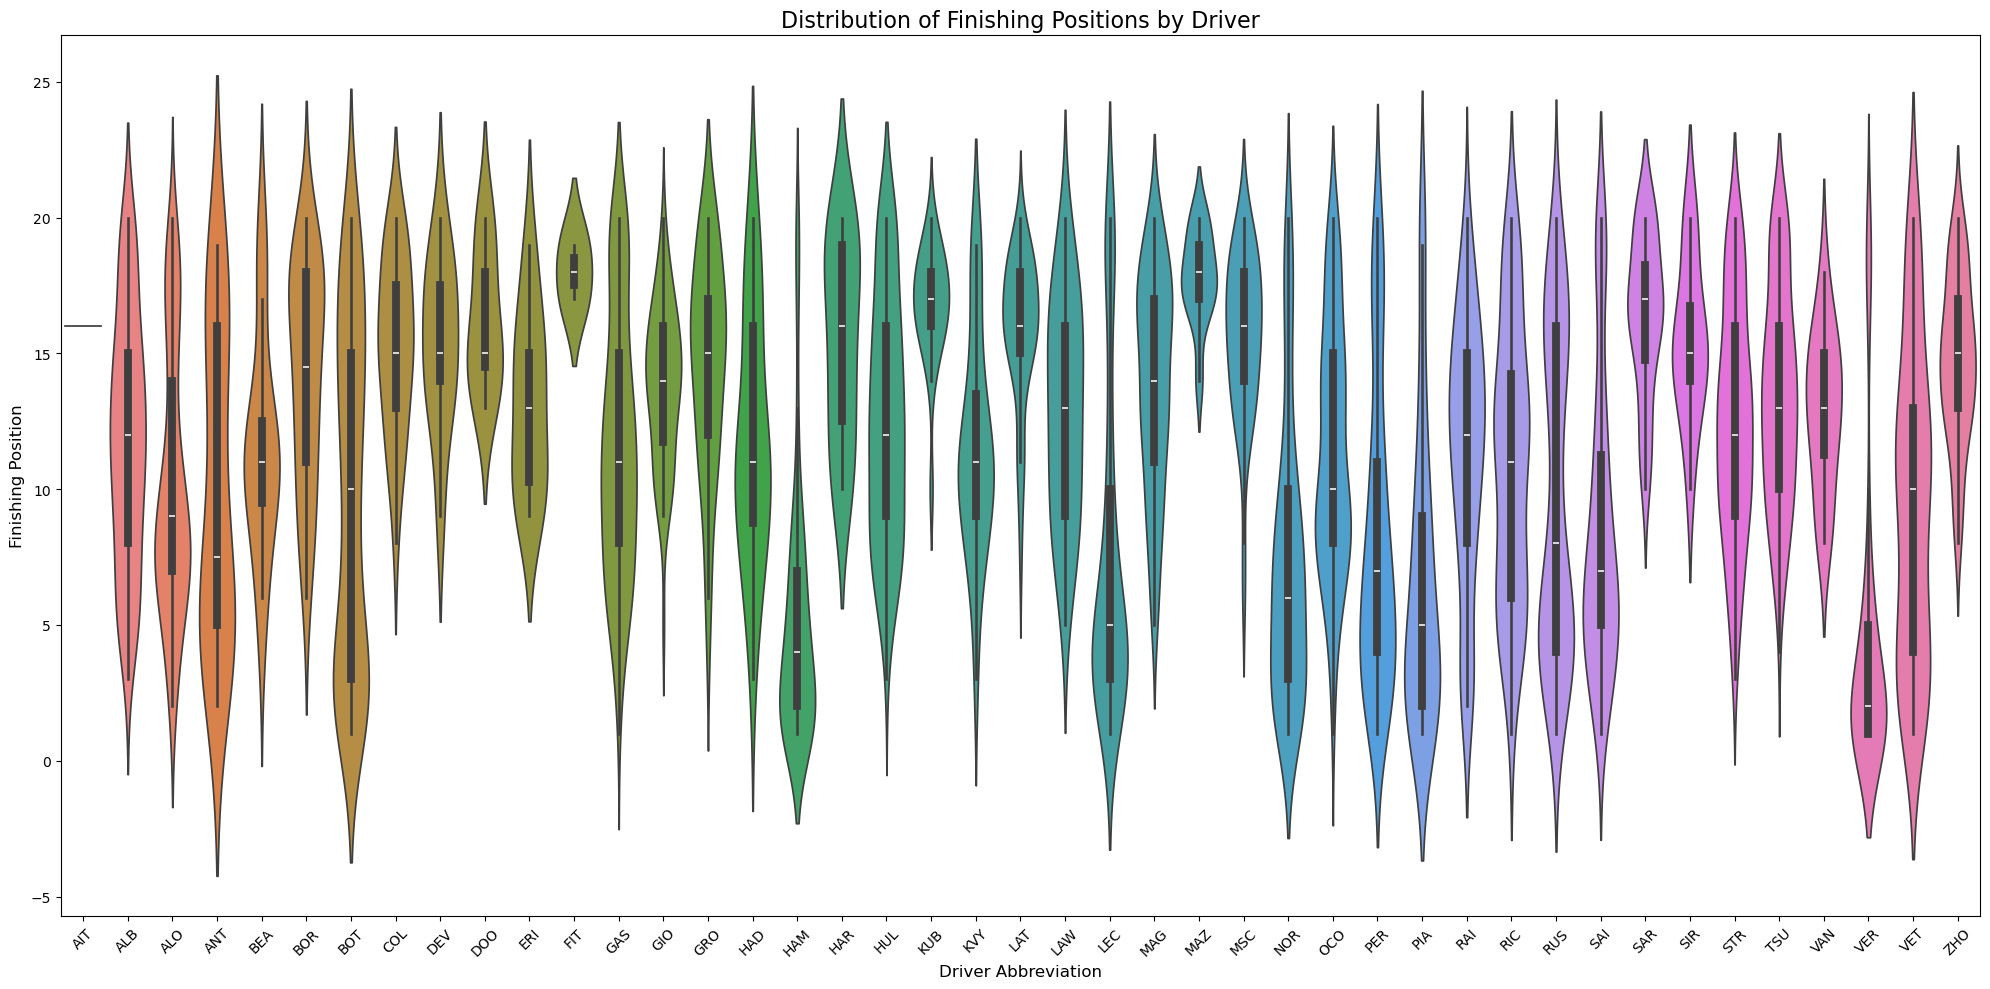

In [19]:
# check if driver name has a different distribution of race finishes
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert the Spark DataFrame to a localized Pandas DataFrame
# (Ensure your dataset has been filtered or aggregated to a reasonable size)
pandas_results = joined_results.toPandas()

# Step 2: Clean up positions by converting them to numeric (ignoring string DNFs)
pandas_results["Position"] = pandas_results["Position"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results = pandas_results.dropna(subset=["Position"])

# Step 3: Sort drivers alphabetically for cleaner visual presentation
pandas_results = pandas_results.sort_values("Abbreviation")

# Step 4: Render the chart
plt.figure(figsize=(20, 10))

# Fixed: Converted data source, removed invalid split=True parameter
sns.violinplot(
    data=pandas_results, 
    x="Abbreviation", 
    y="Position", 
    hue="Abbreviation", 
    legend=False  # Hides massive redundant legend since labels are on the X-axis
)

plt.title("Distribution of Finishing Positions by Driver", fontsize=16)
plt.xlabel("Driver Abbreviation", fontsize=12)
plt.ylabel("Finishing Position", fontsize=12)

plt.xticks(rotation=45) # Rotates labels to prevent clipping on dense charts
plt.tight_layout()
plt.show()


Different drivers have a different distribution of race finishes. Driver name should be kept as a predictor as it informs results based on skill.

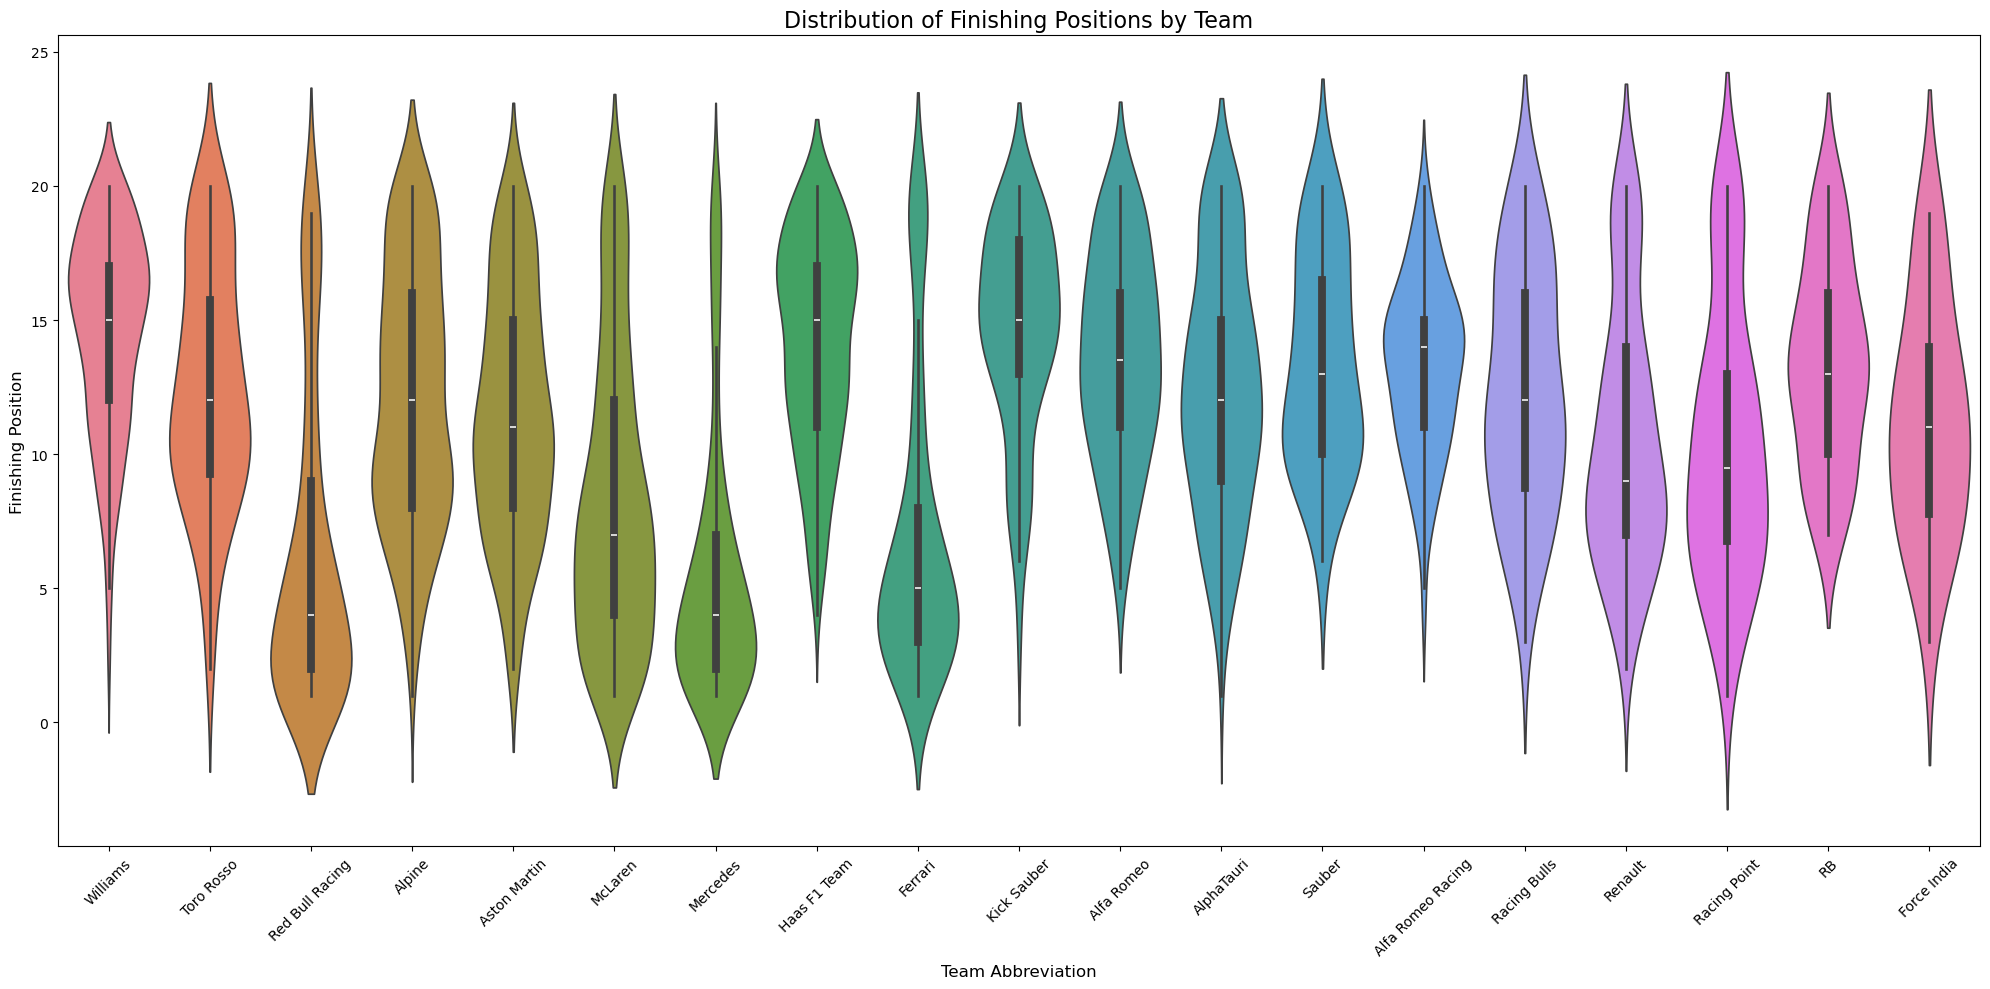

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 4: Render the chart
plt.figure(figsize=(20, 10))

# Fixed: Converted data source, removed invalid split=True parameter
sns.violinplot(
    data=pandas_results, 
    x="TeamName", 
    y="Position", 
    hue="TeamName", 
    legend=False  # Hides massive redundant legend since labels are on the X-axis
)

plt.title("Distribution of Finishing Positions by Team", fontsize=16)
plt.xlabel("Team Abbreviation", fontsize=12)
plt.ylabel("Finishing Position", fontsize=12)

plt.xticks(rotation=45) # Rotates labels to prevent clipping on dense charts
plt.tight_layout()
plt.show()

Different teams have different distribution of finishing results as well. This suggests that different teams have a different baseline of skill, therefore we should keep team name as a predictor.

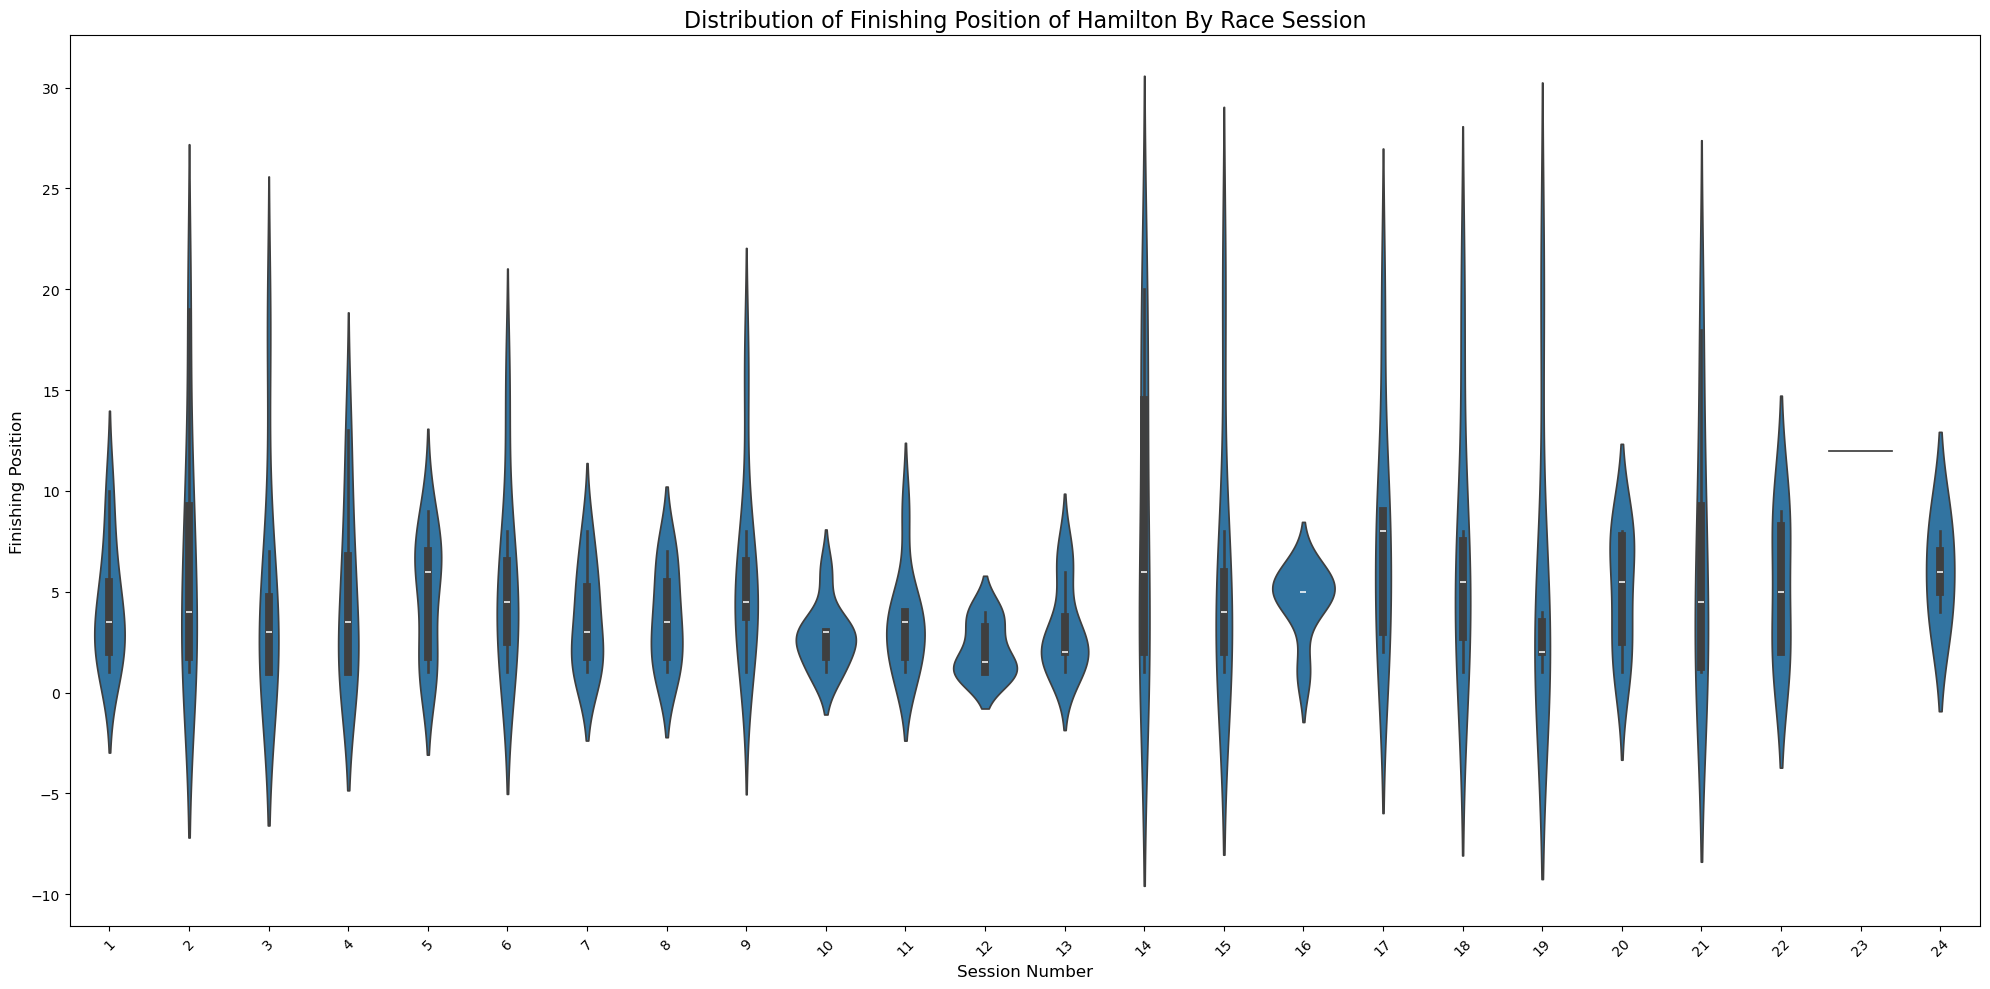

In [25]:
# For a specific driver compare the results for different races
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

# FIX: Correct Pandas boolean indexing syntax
# (If 'pandas_results' is actually a PySpark DataFrame, use: ham_results = pandas_results.filter(pandas_results.Abbreviation == "HAM").toPandas())
ham_results = pandas_results[pandas_results["Abbreviation"] == "HAM"]

# FIX: Seaborn v0.13+ uses 'legend=False' inside the plot function, 
# but make sure your column casing matches exactly (e.g., 'session_number' vs 'sessionnumber')
sns.violinplot(
    data=ham_results, 
    x="session_number",   # Adjusted to match the column name snake_case from your previous script
    y="Position", 
    legend=False  
)

plt.title("Distribution of Finishing Position of Hamilton By Race Session", fontsize=16)

# FIX: Updated label from "Team Abbreviation" to "Session Number" to match the actual X-axis data
plt.xlabel("Session Number", fontsize=12) 
plt.ylabel("Finishing Position", fontsize=12)

plt.xticks(rotation=45) # Rotates labels to prevent clipping on dense charts
plt.tight_layout()
plt.show()


Each session has different result variation, however the session number is not the same as race location. We need to add in the race name for each session.


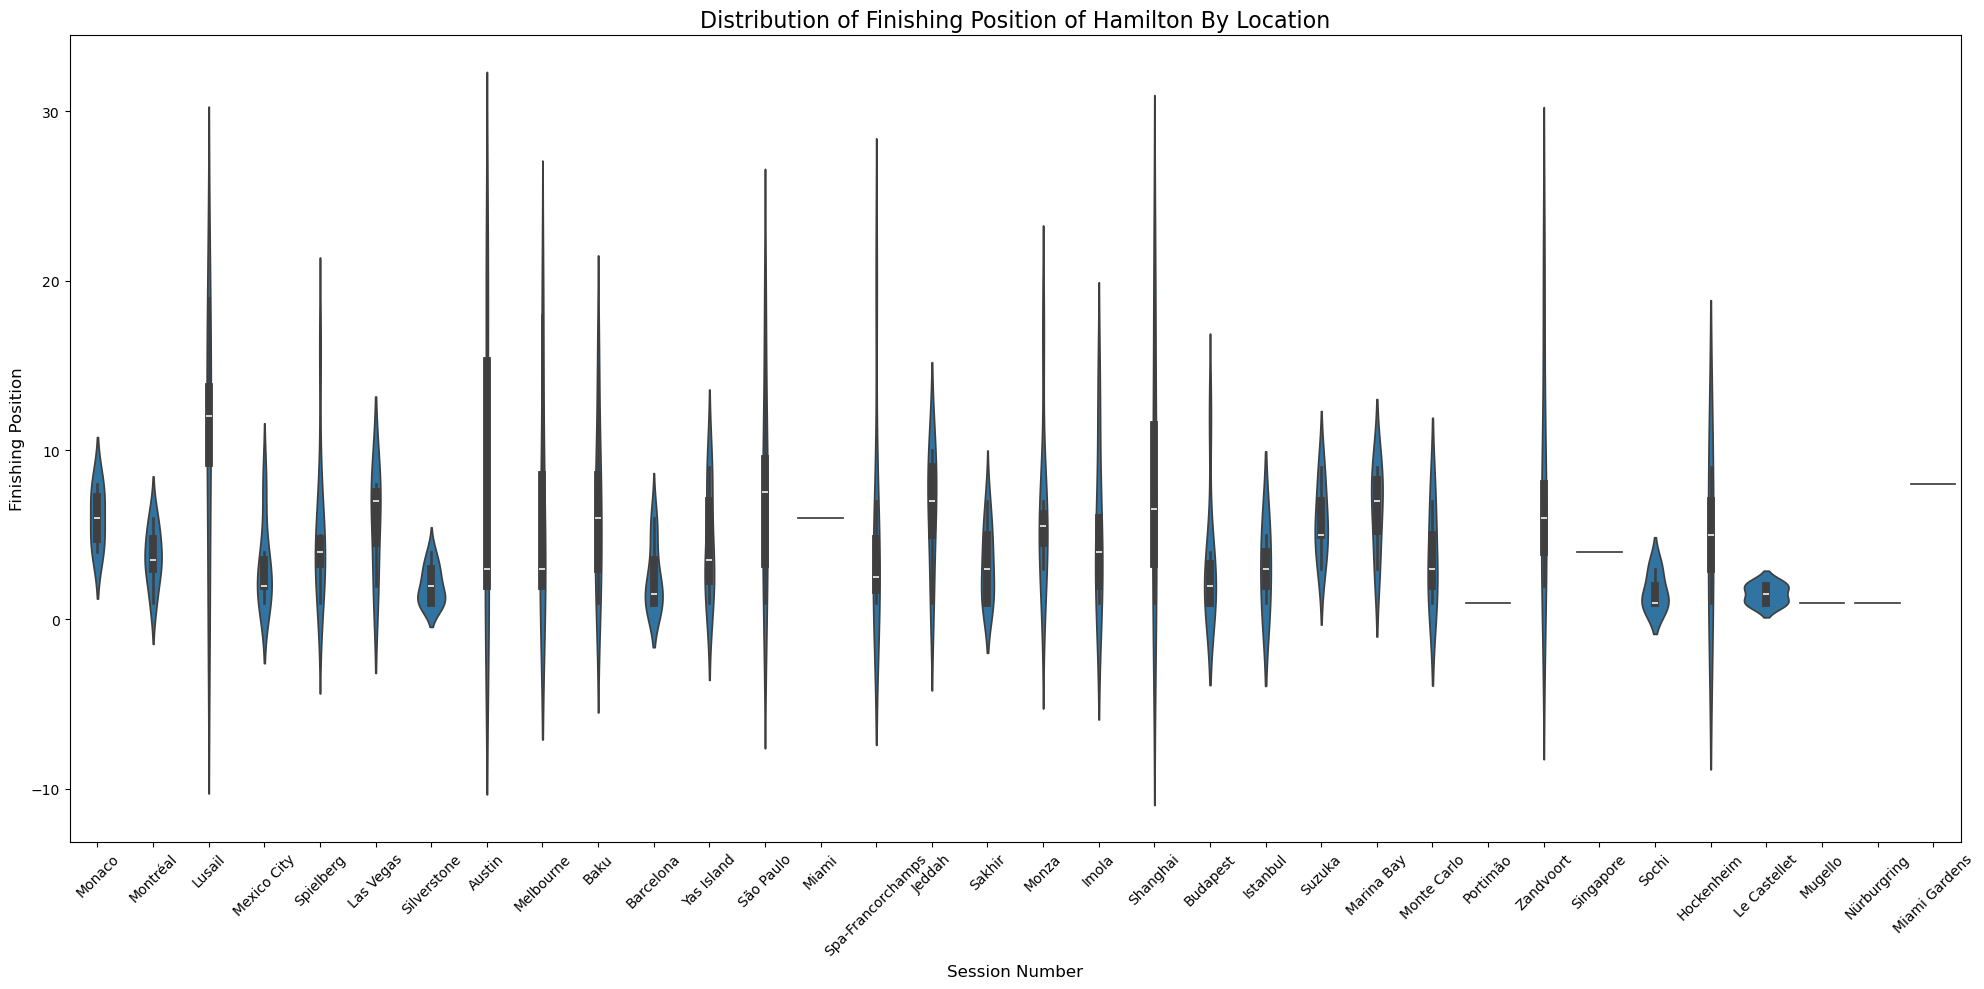

In [20]:
# For a specific driver compare the results for different races
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

pandas_results = joined_results.toPandas()

# FIX: Correct Pandas boolean indexing syntax
# (If 'pandas_results' is actually a PySpark DataFrame, use: ham_results = pandas_results.filter(pandas_results.Abbreviation == "HAM").toPandas())
ham_results = pandas_results[pandas_results["Abbreviation"] == "HAM"]

# FIX: Seaborn v0.13+ uses 'legend=False' inside the plot function, 
# but make sure your column casing matches exactly (e.g., 'session_number' vs 'sessionnumber')
sns.violinplot(
    data=ham_results, 
    x="Location",   # Adjusted to match the column name snake_case from your previous script
    y="Position", 
    legend=False  
)

plt.title("Distribution of Finishing Position of Hamilton By Location", fontsize=16)

# FIX: Updated label from "Team Abbreviation" to "Session Number" to match the actual X-axis data
plt.xlabel("Location", fontsize=12) 
plt.ylabel("Finishing Position", fontsize=12)

plt.xticks(rotation=45) # Rotates labels to prevent clipping on dense charts
plt.tight_layout()
plt.show()


The location based information has a different distribution than the session number. This should be used instead of session number.

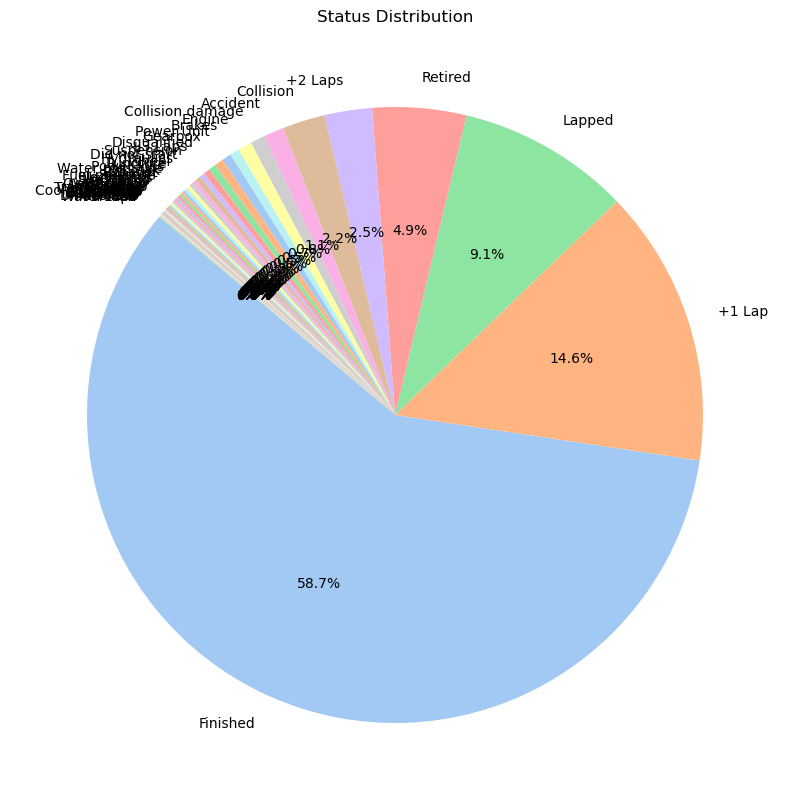

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate your data to get the counts for each status
status_counts = pandas_results['Status'].value_counts()

# Set up your figure size
plt.figure(figsize=(10, 10))

# 2. Use Seaborn's color palettes to keep the Seaborn look
colors = sns.color_palette('pastel')[0:len(status_counts)]

# 3. Create the pie chart using Matplotlib
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',  # Displays the percentage on each wedge
    startangle=140,     # Rotates the start of the pie chart for better alignment
    colors=colors
)

# Set the title
plt.title("Status Distribution")

# Display the chart
plt.show()


Not all races were finished. Only about 59% of statuses were that races were finished. In order to see all of the reasons that race was not finished view the table below.


In [45]:
import pandas as pd

# 1. Calculate raw counts
counts = pandas_results['Status'].value_counts()

# 2. Calculate percentages
percentages = pandas_results['Status'].value_counts(normalize=True) * 100

# 3. Combine them into a clean DataFrame
status_table = pd.DataFrame({
    'Count': counts,
    'Percentage': percentages
})

# 4. Give the index column a proper name
status_table.index.name = 'Status'

# Display the table
print(status_table)


                  Count  Percentage
Status                             
Finished           1924   58.748092
+1 Lap              477   14.564885
Lapped              297    9.068702
Retired             161    4.916031
+2 Laps              82    2.503817
Collision            73    2.229008
Accident             35    1.068702
Collision damage     25    0.763359
Engine               24    0.732824
Brakes               16    0.488550
Power Unit           16    0.488550
Gearbox              15    0.458015
Disqualified         13    0.396947
+3 Laps              11    0.335878
Suspension            9    0.274809
Did not start         9    0.274809
Hydraulics            7    0.213740
Wheel                 7    0.213740
Puncture              6    0.183206
Power loss            6    0.183206
Water pressure        4    0.122137
Oil leak              4    0.122137
Exhaust               4    0.122137
Spun off              4    0.122137
Fuel pressure         4    0.122137
Electronics           3    0

Let's compare this for different drivers


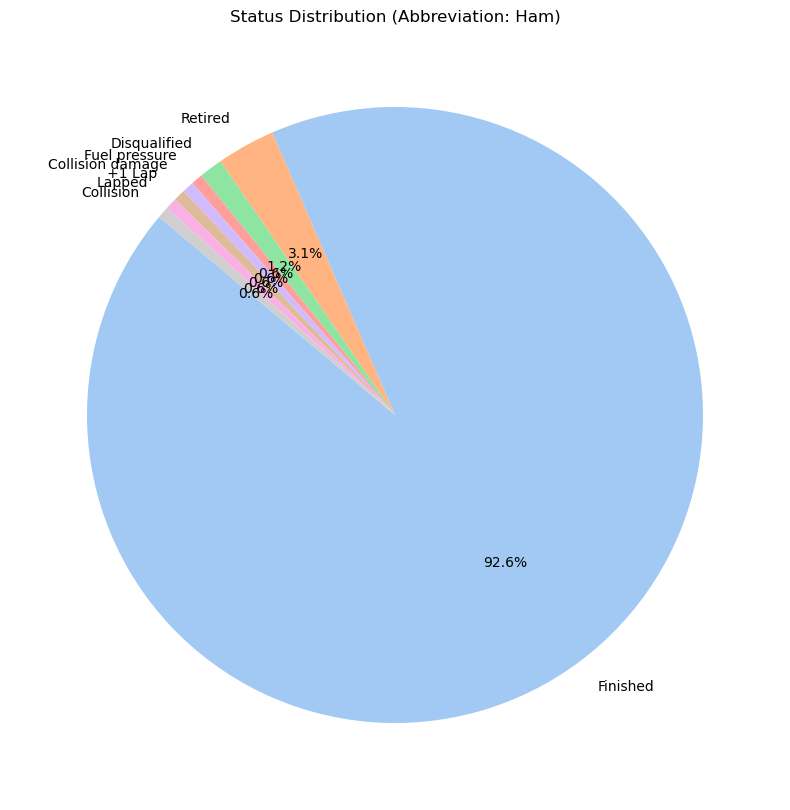

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset where the Abbreviation column is exactly "Ham"
ham_results = pandas_results[pandas_results['Abbreviation'] == 'HAM']

# 2. Aggregate the filtered data to get the counts for each status
status_counts = ham_results['Status'].value_counts()

# Set up your figure size
plt.figure(figsize=(10, 10))

# 3. Use Seaborn's color palettes to keep the Seaborn look
colors = sns.color_palette('pastel')[0:len(status_counts)]

# 4. Create the pie chart using Matplotlib
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',  # Displays the percentage on each wedge
    startangle=140,     # Rotates the start of the pie chart for better alignment
    colors=colors
)

# Set the title to reflect the filter
plt.title("Status Distribution (Abbreviation: Ham)")

# Display the chart
plt.show()


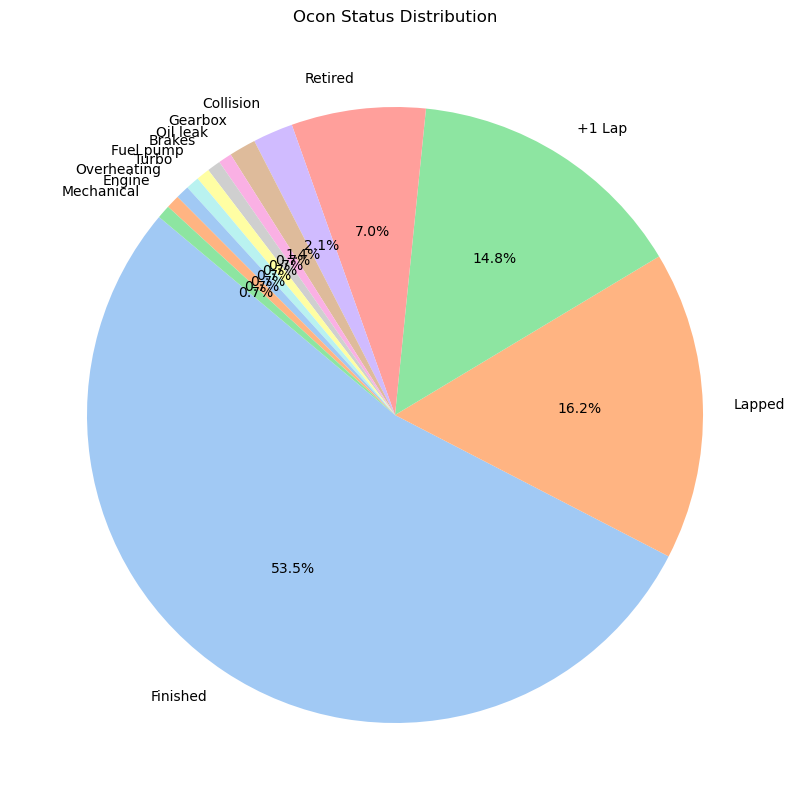

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

oco_results = pandas_results[pandas_results['Abbreviation'] == 'OCO']

# 2. Aggregate the filtered data to get the counts for each status
status_counts = oco_results['Status'].value_counts()

# Set up your figure size
plt.figure(figsize=(10, 10))

# 3. Use Seaborn's color palettes to keep the Seaborn look
colors = sns.color_palette('pastel')[0:len(status_counts)]

# 4. Create the pie chart using Matplotlib
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',  # Displays the percentage on each wedge
    startangle=140,     # Rotates the start of the pie chart for better alignment
    colors=colors
)

# Set the title to reflect the filter
plt.title("Ocon Status Distribution")

# Display the chart
plt.show()


Hamilton and Occon have two different distribution of statuses. This indicates variance among the drivers for how they finish the race.

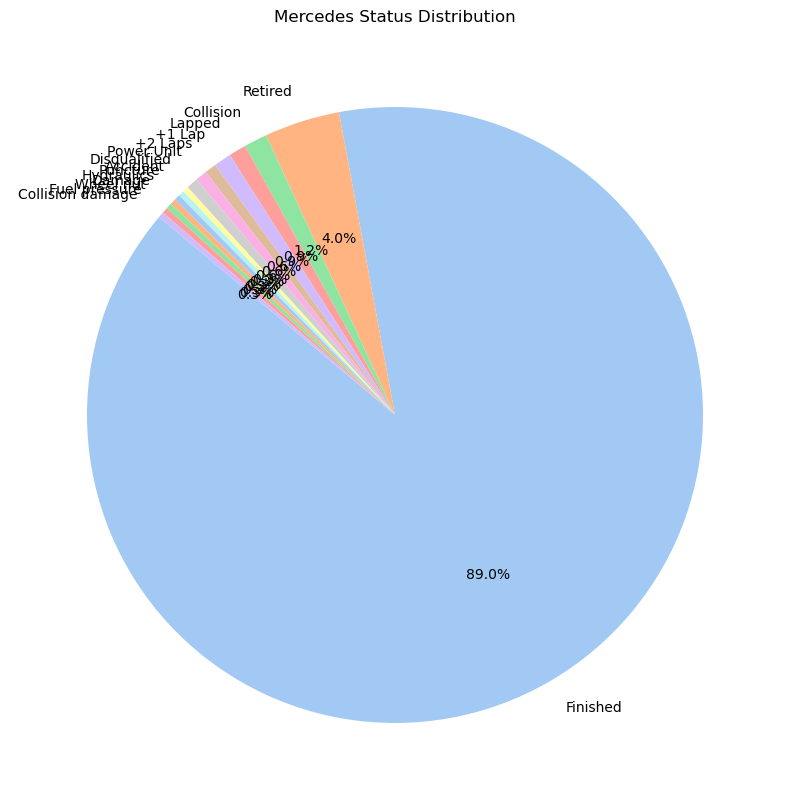

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset where the Abbreviation column is exactly "Mercedes"
merc_results = pandas_results[pandas_results['TeamName'] == 'Mercedes']

# 2. Aggregate the filtered data to get the counts for each status
status_counts = merc_results['Status'].value_counts()

# Set up your figure size
plt.figure(figsize=(10, 10))

# 3. Use Seaborn's color palettes to keep the Seaborn look
colors = sns.color_palette('pastel')[0:len(status_counts)]

# 4. Create the pie chart using Matplotlib
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',  # Displays the percentage on each wedge
    startangle=140,     # Rotates the start of the pie chart for better alignment
    colors=colors
)

# Set the title to reflect the filter
plt.title("Mercedes Status Distribution")

# Display the chart
plt.show()


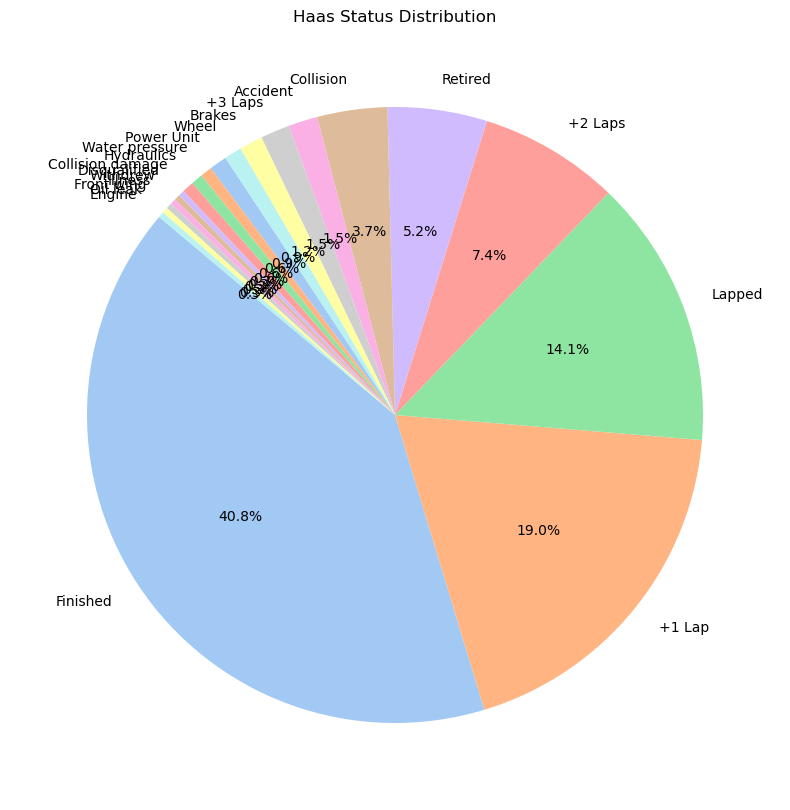

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset where the Abbreviation column is exactly "Mercedes"
haas_results = pandas_results[pandas_results['TeamName'] == 'Haas F1 Team']

# 2. Aggregate the filtered data to get the counts for each status
status_counts = haas_results['Status'].value_counts()

# Set up your figure size
plt.figure(figsize=(10, 10))

# 3. Use Seaborn's color palettes to keep the Seaborn look
colors = sns.color_palette('pastel')[0:len(status_counts)]

# 4. Create the pie chart using Matplotlib
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',  # Displays the percentage on each wedge
    startangle=140,     # Rotates the start of the pie chart for better alignment
    colors=colors
)

# Set the title to reflect the filter
plt.title("Haas Status Distribution")

# Display the chart
plt.show()


Even based on the team there is a difference between end race status. We should include this predictor in the model but check if it is correlated with finishing position. As if you don't finish the race, this would indicate that you received a lower place.

/tmp/ipykernel_639314/2683099513.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


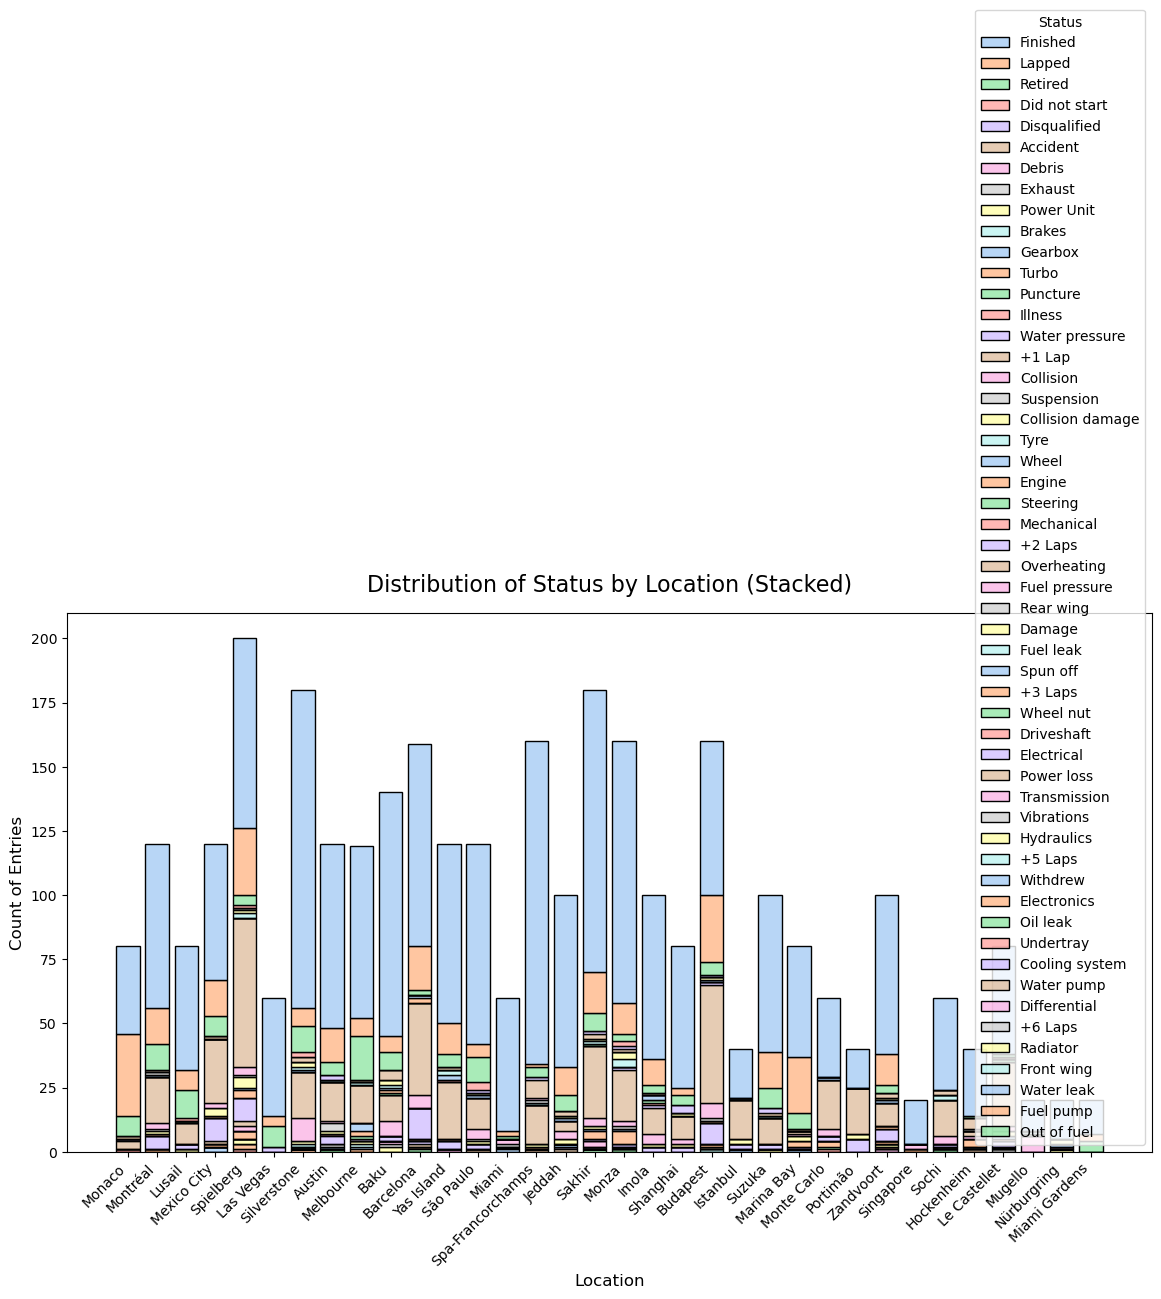

In [23]:
# check the distribution of status by location
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a wide figure size so your locations fit nicely
plt.figure(figsize=(14, 7))

# Create the stacked bar chart using histplot
sns.histplot(
    x="Location", 
    hue="Status", 
    data=pandas_results, 
    multiple="stack",   # This forces the categories to stack instead of grouping side-by-side
    palette="pastel",   # Uses Seaborn's modern, soft coloring scheme
    shrink=0.8          # Creates clean gaps between each location bar
)

# Style your labels, title, and layout
plt.title("Distribution of Status by Location (Stacked)", fontsize=16, pad=15)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Count of Entries", fontsize=12)

# Rotate the location labels on the X-axis so they don't overlap each other
plt.xticks(rotation=45, ha='right')

# Automatically prevents edge cutting and displays the chart
plt.tight_layout()
plt.show()




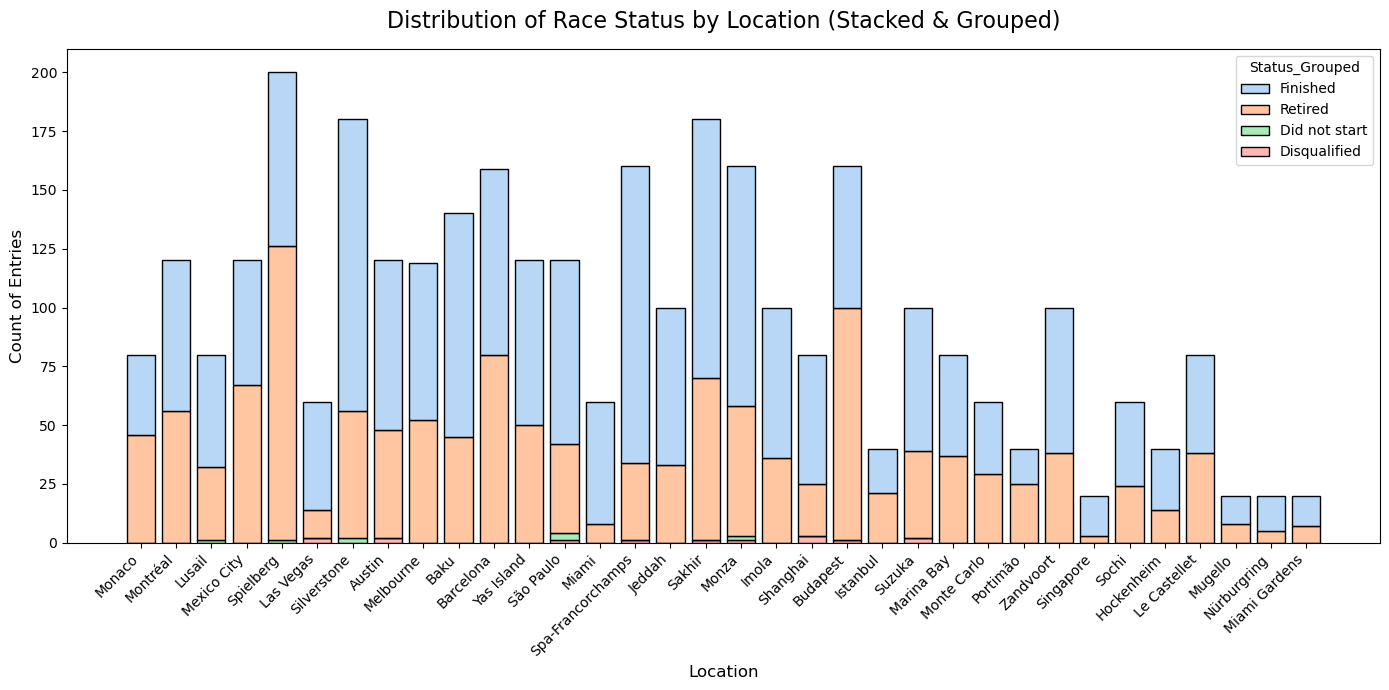

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a copy of the results dataframe to avoid modifying your original data
df_clean = pandas_results.copy()

# Ensure the Status column values are stripped of extra spaces and cast as strings
df_clean['Status_Grouped'] = df_clean['Status'].astype(str).str.strip()

# 2. Identify the statuses you want to keep exactly as they are
keep_statuses = ["Finished", "Did not start", "Disqualified"]

# 3. Use the ~ (NOT) operator to find everything else and change it to "Retired"
df_clean.loc[~df_clean['Status_Grouped'].isin(keep_statuses), 'Status_Grouped'] = 'Retired'

# Set up your figure size
plt.figure(figsize=(14, 7))

# 4. Create the stacked bar chart using your new grouped column as the hue
sns.histplot(
    x="Location", 
    hue="Status_Grouped", 
    data=df_clean, 
    multiple="stack",   
    palette="pastel",   
    shrink=0.8          
)

# Style your labels, title, and layout
plt.title("Distribution of Race Status by Location (Stacked & Grouped)", fontsize=16, pad=15)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Count of Entries", fontsize=12)

# Rotate labels so they don't overlap
plt.xticks(rotation=45, ha='right')

# Fix layout bounding boxes and display
plt.tight_layout()
plt.show()


Different race locations have a different distribution of status. If we then simplify everything to finished, retired, did not start, and disqualified, we can use the information to predict the points subtracted for F1 Fantasy.

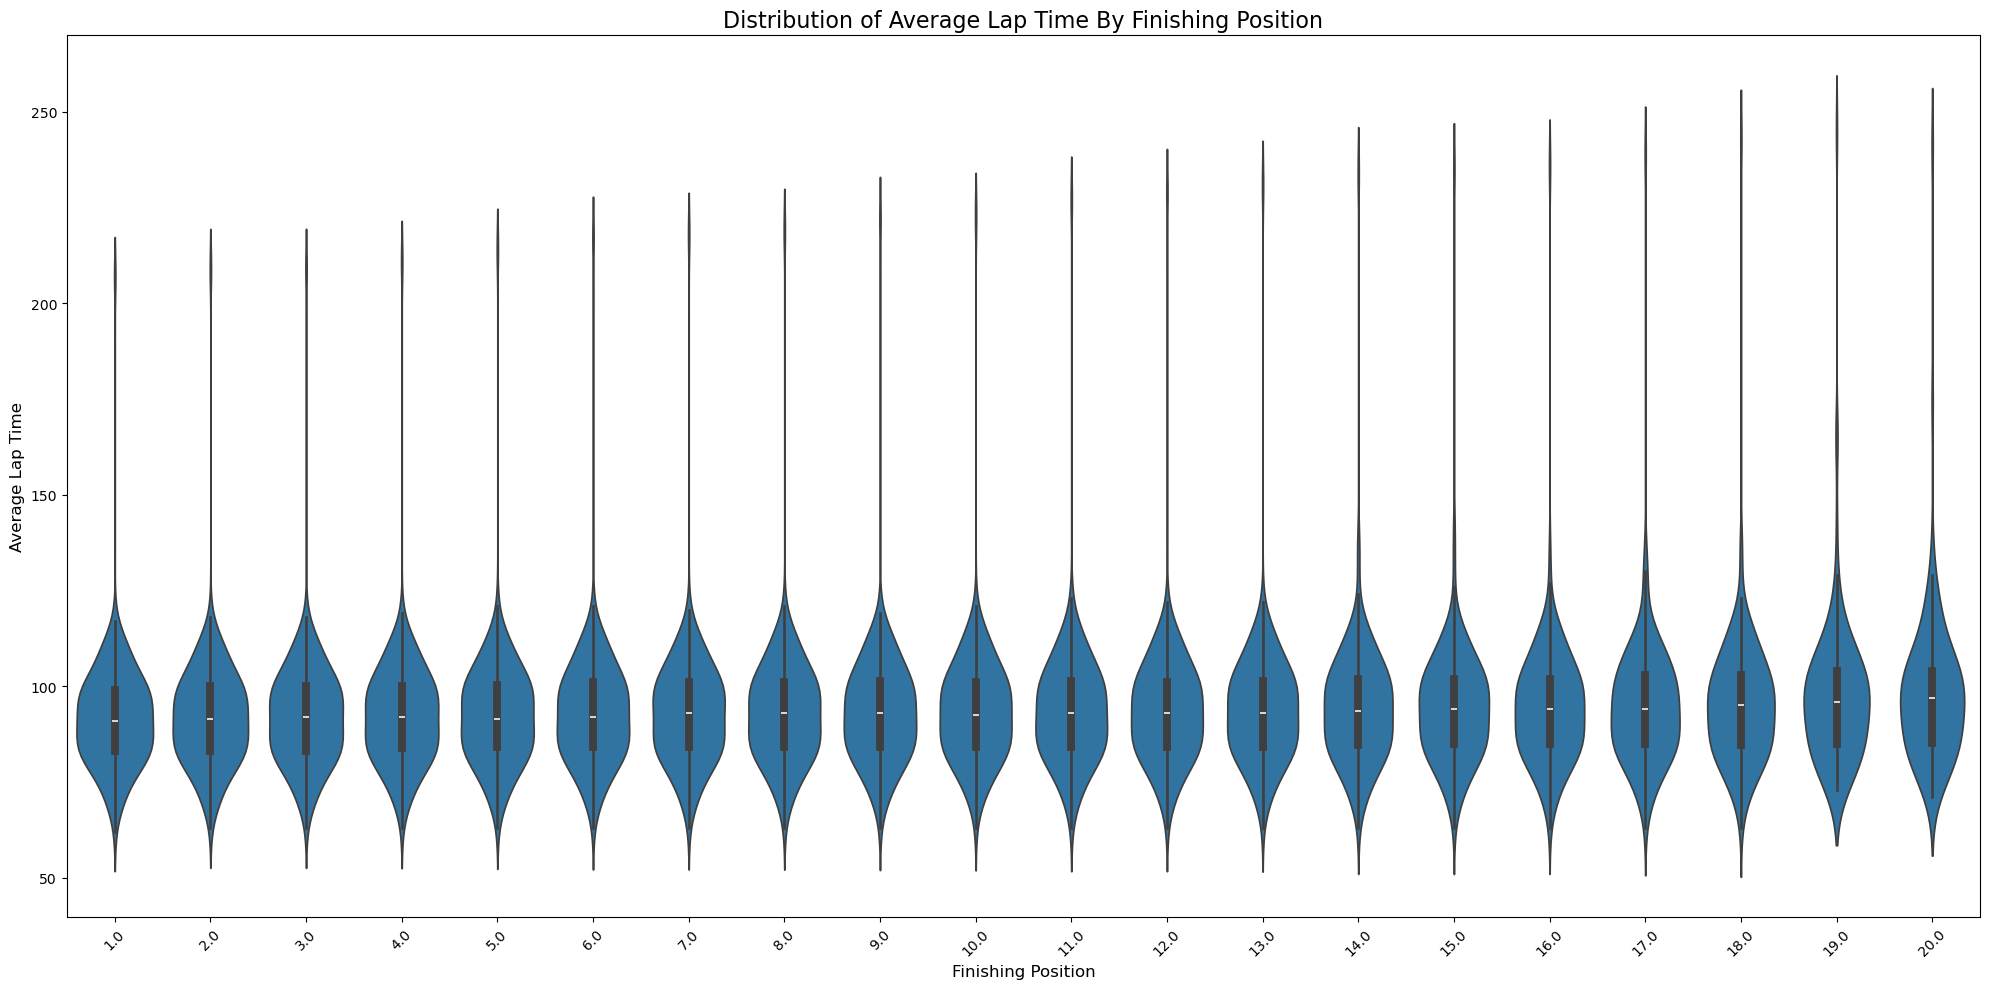

In [54]:
# Check the distribution of lap times based on finishing positions.
# Is there a clear difference in lap times and finishing positions

import seaborn as sns
import matplotlib.pyplot as plt

# Step 4: Render the chart
plt.figure(figsize=(20, 10))

# Fixed: Converted data source, removed invalid split=True parameter
sns.violinplot(
    data=pandas_results, 
    x="Position", 
    y="avg_lap_time_seconds", 
    legend=False  # Hides massive redundant legend since labels are on the X-axis
)

plt.title("Distribution of Average Lap Time By Finishing Position", fontsize=16)
plt.xlabel("Finishing Position", fontsize=12)
plt.ylabel("Average Lap Time", fontsize=12)

plt.xticks(rotation=45) # Rotates labels to prevent clipping on dense charts
plt.tight_layout()
plt.show()

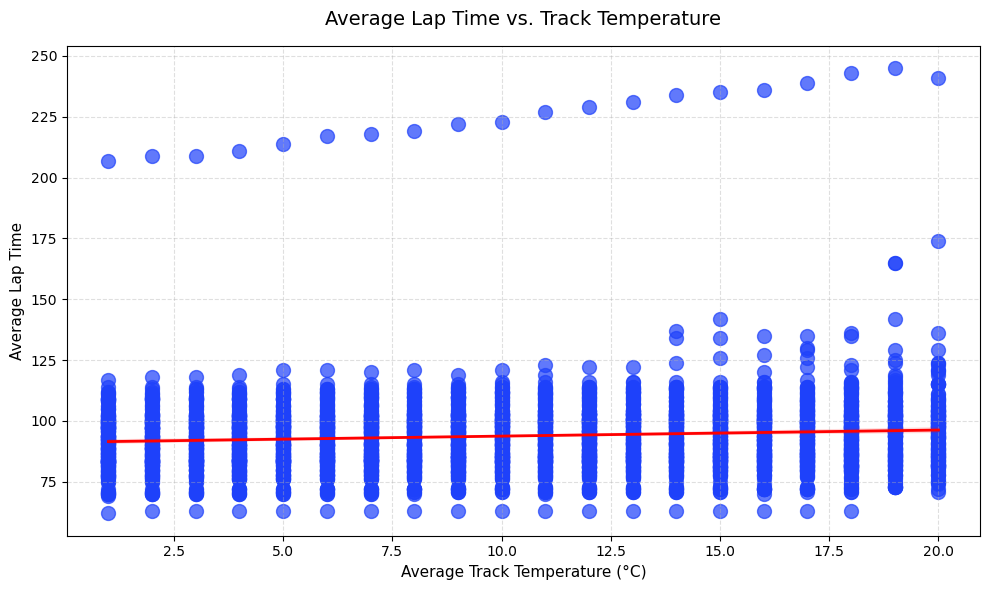

In [55]:
# Check the weather data
#Compare a driver's results with the trackTemp
import seaborn as sns
import matplotlib.pyplot as plt


# 2. Ensure data types are numeric and clean missing values
pandas_results["avg_lap_time_seconds"] = pandas_results["avg_lap_time_seconds"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results["avg_track_temp"] = pandas_results["avg_track_temp"].astype(float)
pandas_results = pandas_results.dropna(subset=["Position", "avg_lap_time_seconds"])

# 3. Create the scatter plot with a regression trend line
plt.figure(figsize=(10, 6))

# regplot adds a helpful trend line over the scatter points
sns.regplot(
    data=pandas_results,
    x="Position",
    y="avg_lap_time_seconds",
    scatter_kws={"s": 100, "alpha": 0.7, "color": "#1E41FA"},  # Style for the dots (Blue)
    line_kws={"color": "#FF0000", "linewidth": 2}              # Style for the trend line (Red)
)

# 4. Polish the presentation
plt.title("Average Lap Time vs. Position", fontsize=14, pad=15)
plt.xlabel("Position", fontsize=11)
plt.ylabel("Average Lap Time", fontsize=11)





plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



There is a slight increase but I would not recommend for us to use it as a predictor.

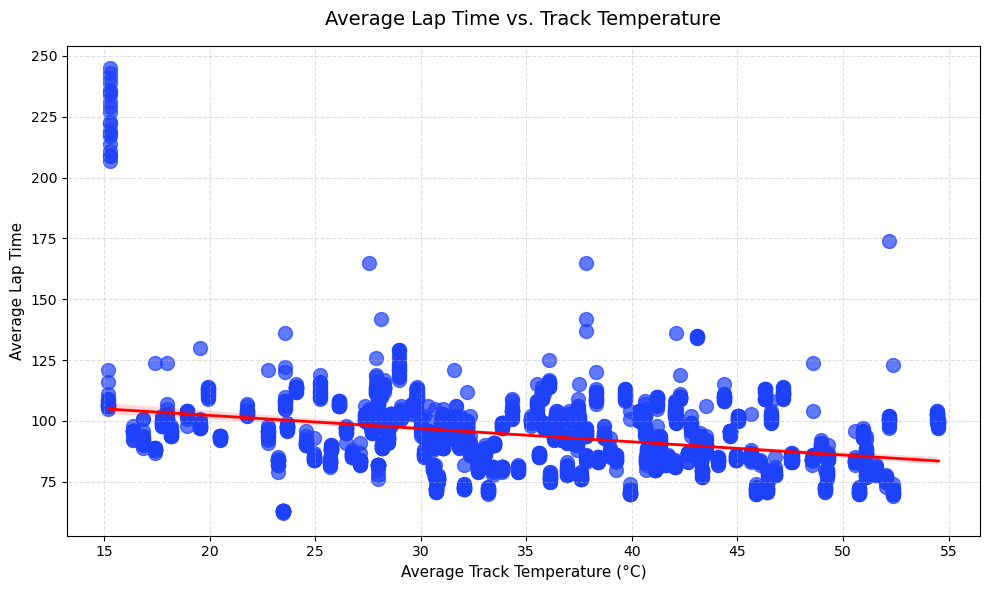

In [21]:
# Check the weather data
#Compare a driver's results with the trackTemp
import seaborn as sns
import matplotlib.pyplot as plt


# 2. Ensure data types are numeric and clean missing values
pandas_results["avg_lap_time_seconds"] = pandas_results["avg_lap_time_seconds"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results["avg_track_temp"] = pandas_results["avg_track_temp"].astype(float)
pandas_results = pandas_results.dropna(subset=["Position", "avg_track_temp"])

# 3. Create the scatter plot with a regression trend line
plt.figure(figsize=(10, 6))

# regplot adds a helpful trend line over the scatter points
sns.regplot(
    data=pandas_results,
    x="avg_track_temp",
    y="avg_lap_time_seconds",
    scatter_kws={"s": 100, "alpha": 0.7, "color": "#1E41FA"},  # Style for the dots (Blue)
    line_kws={"color": "#FF0000", "linewidth": 2}              # Style for the trend line (Red)
)

# 4. Polish the presentation
plt.title("Average Lap Time vs. Track Temperature", fontsize=14, pad=15)
plt.xlabel("Average Track Temperature (°C)", fontsize=11)
plt.ylabel("Average Lap Time", fontsize=11)





plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



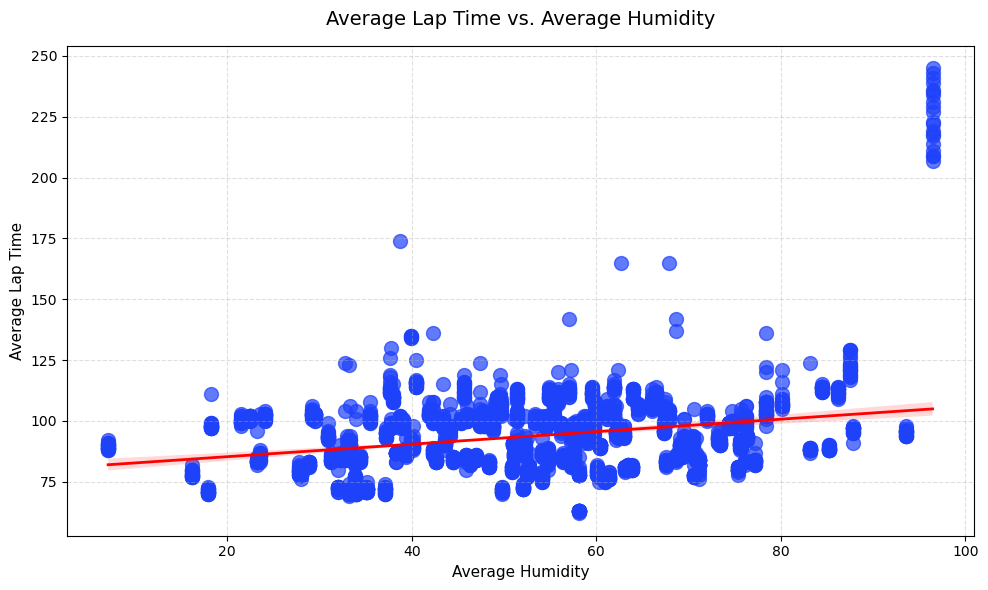

In [57]:
#Compare a driver's results with the trackTemp
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Ensure data types are numeric and clean missing values
pandas_results["avg_lap_time_seconds"] = pandas_results["avg_lap_time_seconds"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results["avg_humidity"] = pandas_results["avg_humidity"].astype(float)
pandas_results = pandas_results.dropna(subset=["avg_lap_time_seconds", "avg_humidity"])

# 3. Create the scatter plot with a regression trend line
plt.figure(figsize=(10, 6))

# regplot adds a helpful trend line over the scatter points
sns.regplot(
    data=pandas_results,
    x="avg_humidity",
    y="avg_lap_time_seconds",
    scatter_kws={"s": 100, "alpha": 0.7, "color": "#1E41FA"},  # Style for the dots (Blue)
    line_kws={"color": "#FF0000", "linewidth": 2}              # Style for the trend line (Red)
)

# 4. Polish the presentation
plt.title("Average Lap Time vs. Average Humidity", fontsize=14, pad=15)
plt.xlabel("Average Humidity", fontsize=11)
plt.ylabel("Average Lap Time", fontsize=11)





plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



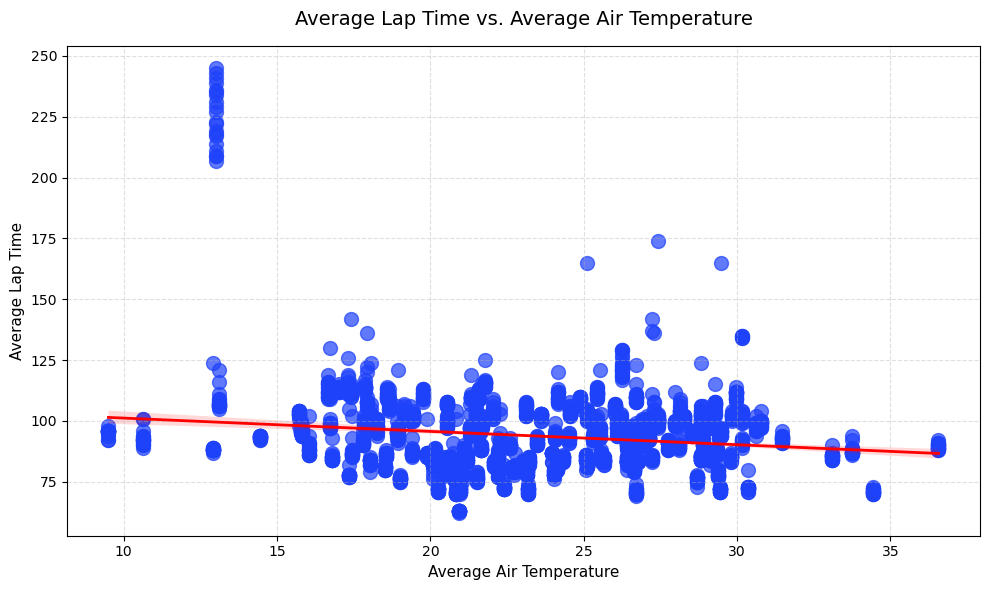

In [58]:
#Compare a driver's results with the trackTemp
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Ensure data types are numeric and clean missing values
pandas_results["avg_lap_time_seconds"] = pandas_results["avg_lap_time_seconds"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results["avg_air_temp"] = pandas_results["avg_air_temp"].astype(float)
pandas_results = pandas_results.dropna(subset=["avg_lap_time_seconds", "avg_air_temp"])

# 3. Create the scatter plot with a regression trend line
plt.figure(figsize=(10, 6))

# regplot adds a helpful trend line over the scatter points
sns.regplot(
    data=pandas_results,
    x="avg_air_temp",
    y="avg_lap_time_seconds",
    scatter_kws={"s": 100, "alpha": 0.7, "color": "#1E41FA"},  # Style for the dots (Blue)
    line_kws={"color": "#FF0000", "linewidth": 2}              # Style for the trend line (Red)
)

# 4. Polish the presentation
plt.title("Average Lap Time vs. Average Air Temperature", fontsize=14, pad=15)
plt.xlabel("Average Air Temperature", fontsize=11)
plt.ylabel("Average Lap Time", fontsize=11)





plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



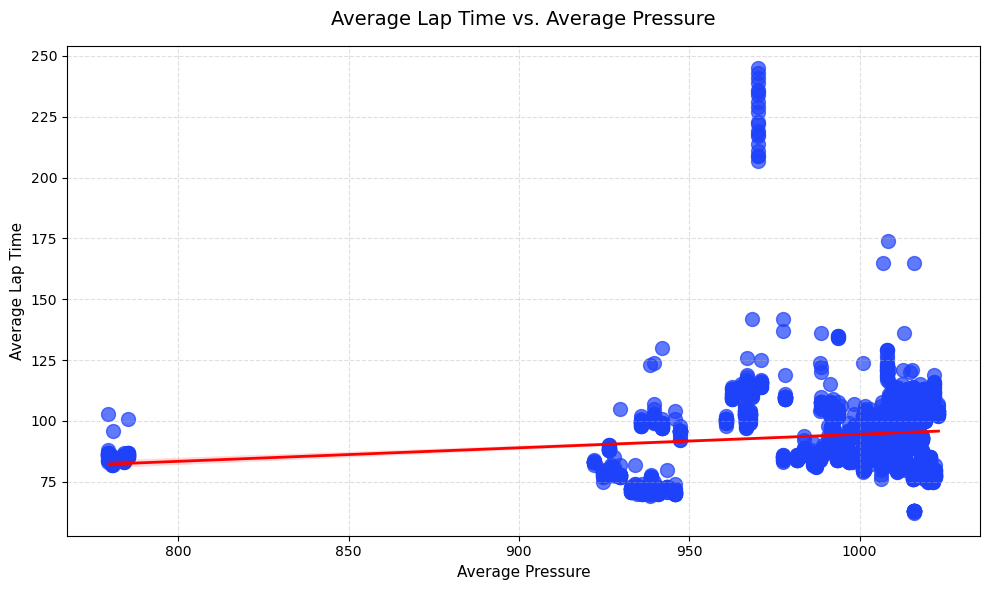

In [59]:


#Compare a driver's results with the trackTemp
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Ensure data types are numeric and clean missing values
pandas_results["avg_lap_time_seconds"] = pandas_results["avg_lap_time_seconds"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results["avg_pressure"] = pandas_results["avg_pressure"].astype(float)
pandas_results = pandas_results.dropna(subset=["avg_lap_time_seconds", "avg_air_temp"])

# 3. Create the scatter plot with a regression trend line
plt.figure(figsize=(10, 6))

# regplot adds a helpful trend line over the scatter points
sns.regplot(
    data=pandas_results,
    x="avg_pressure",
    y="avg_lap_time_seconds",
    scatter_kws={"s": 100, "alpha": 0.7, "color": "#1E41FA"},  # Style for the dots (Blue)
    line_kws={"color": "#FF0000", "linewidth": 2}              # Style for the trend line (Red)
)

# 4. Polish the presentation
plt.title("Average Lap Time vs. Average Pressure", fontsize=14, pad=15)
plt.xlabel("Average Pressure", fontsize=11)
plt.ylabel("Average Lap Time", fontsize=11)





plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



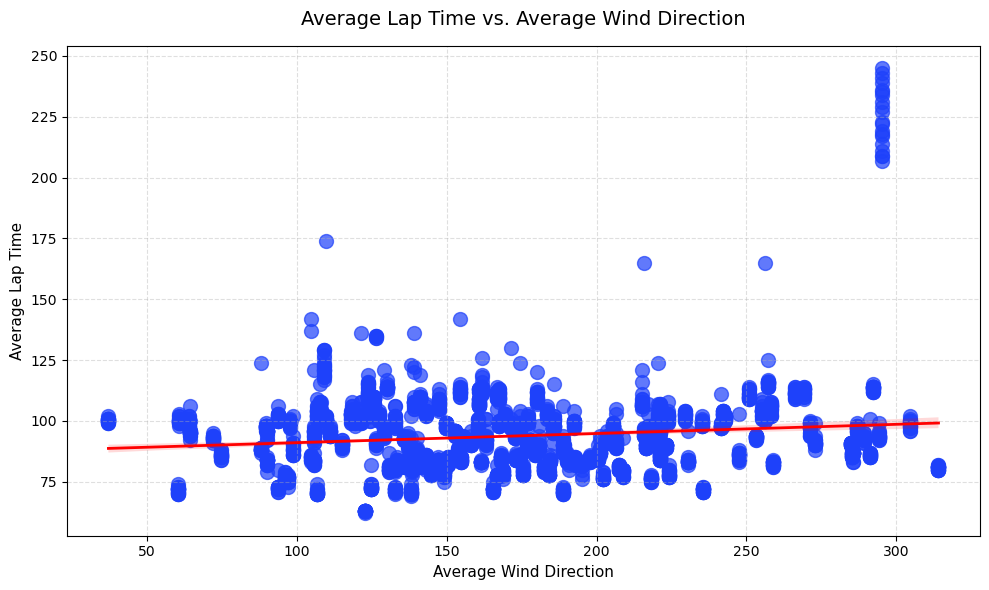

In [60]:

#Compare a driver's results with the trackTemp
import seaborn as sns
import matplotlib.pyplot as plt


# 2. Ensure data types are numeric and clean missing values
pandas_results["avg_lap_time_seconds"] = pandas_results["avg_lap_time_seconds"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results["avg_wind_direction"] = pandas_results["avg_wind_direction"].astype(float)
pandas_results = pandas_results.dropna(subset=["avg_lap_time_seconds", "avg_air_temp"])

# 3. Create the scatter plot with a regression trend line
plt.figure(figsize=(10, 6))

# regplot adds a helpful trend line over the scatter points
sns.regplot(
    data=pandas_results,
    x="avg_wind_direction",
    y="avg_lap_time_seconds",
    scatter_kws={"s": 100, "alpha": 0.7, "color": "#1E41FA"},  # Style for the dots (Blue)
    line_kws={"color": "#FF0000", "linewidth": 2}              # Style for the trend line (Red)
)

# 4. Polish the presentation
plt.title("Average Lap Time vs. Average Wind Direction", fontsize=14, pad=15)
plt.xlabel("Average Wind Direction", fontsize=11)
plt.ylabel("Average Lap Time", fontsize=11)





plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



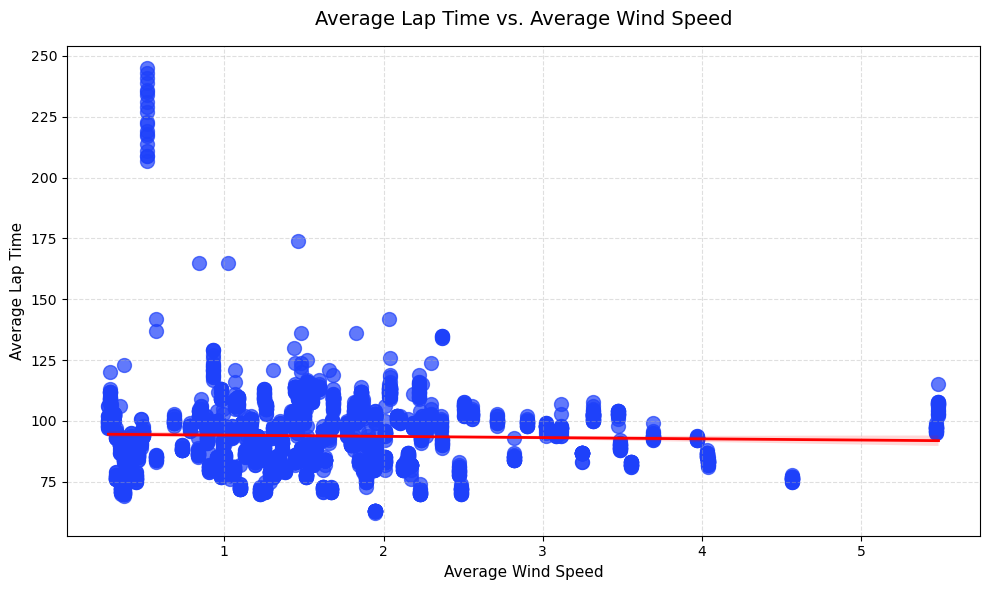

In [61]:

#Compare a driver's results with the trackTemp
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Ensure data types are numeric and clean missing values
pandas_results["avg_lap_time_seconds"] = pandas_results["avg_lap_time_seconds"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results["avg_wind_speed"] = pandas_results["avg_wind_speed"].astype(float)
pandas_results = pandas_results.dropna(subset=["avg_lap_time_seconds", "avg_air_temp"])

# 3. Create the scatter plot with a regression trend line
plt.figure(figsize=(10, 6))

# regplot adds a helpful trend line over the scatter points
sns.regplot(
    data=pandas_results,
    x="avg_wind_speed",
    y="avg_lap_time_seconds",
    scatter_kws={"s": 100, "alpha": 0.7, "color": "#1E41FA"},  # Style for the dots (Blue)
    line_kws={"color": "#FF0000", "linewidth": 2}              # Style for the trend line (Red)
)

# 4. Polish the presentation
plt.title("Average Lap Time vs. Average Wind Speed", fontsize=14, pad=15)
plt.xlabel("Average Wind Speed", fontsize=11)
plt.ylabel("Average Lap Time", fontsize=11)





plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



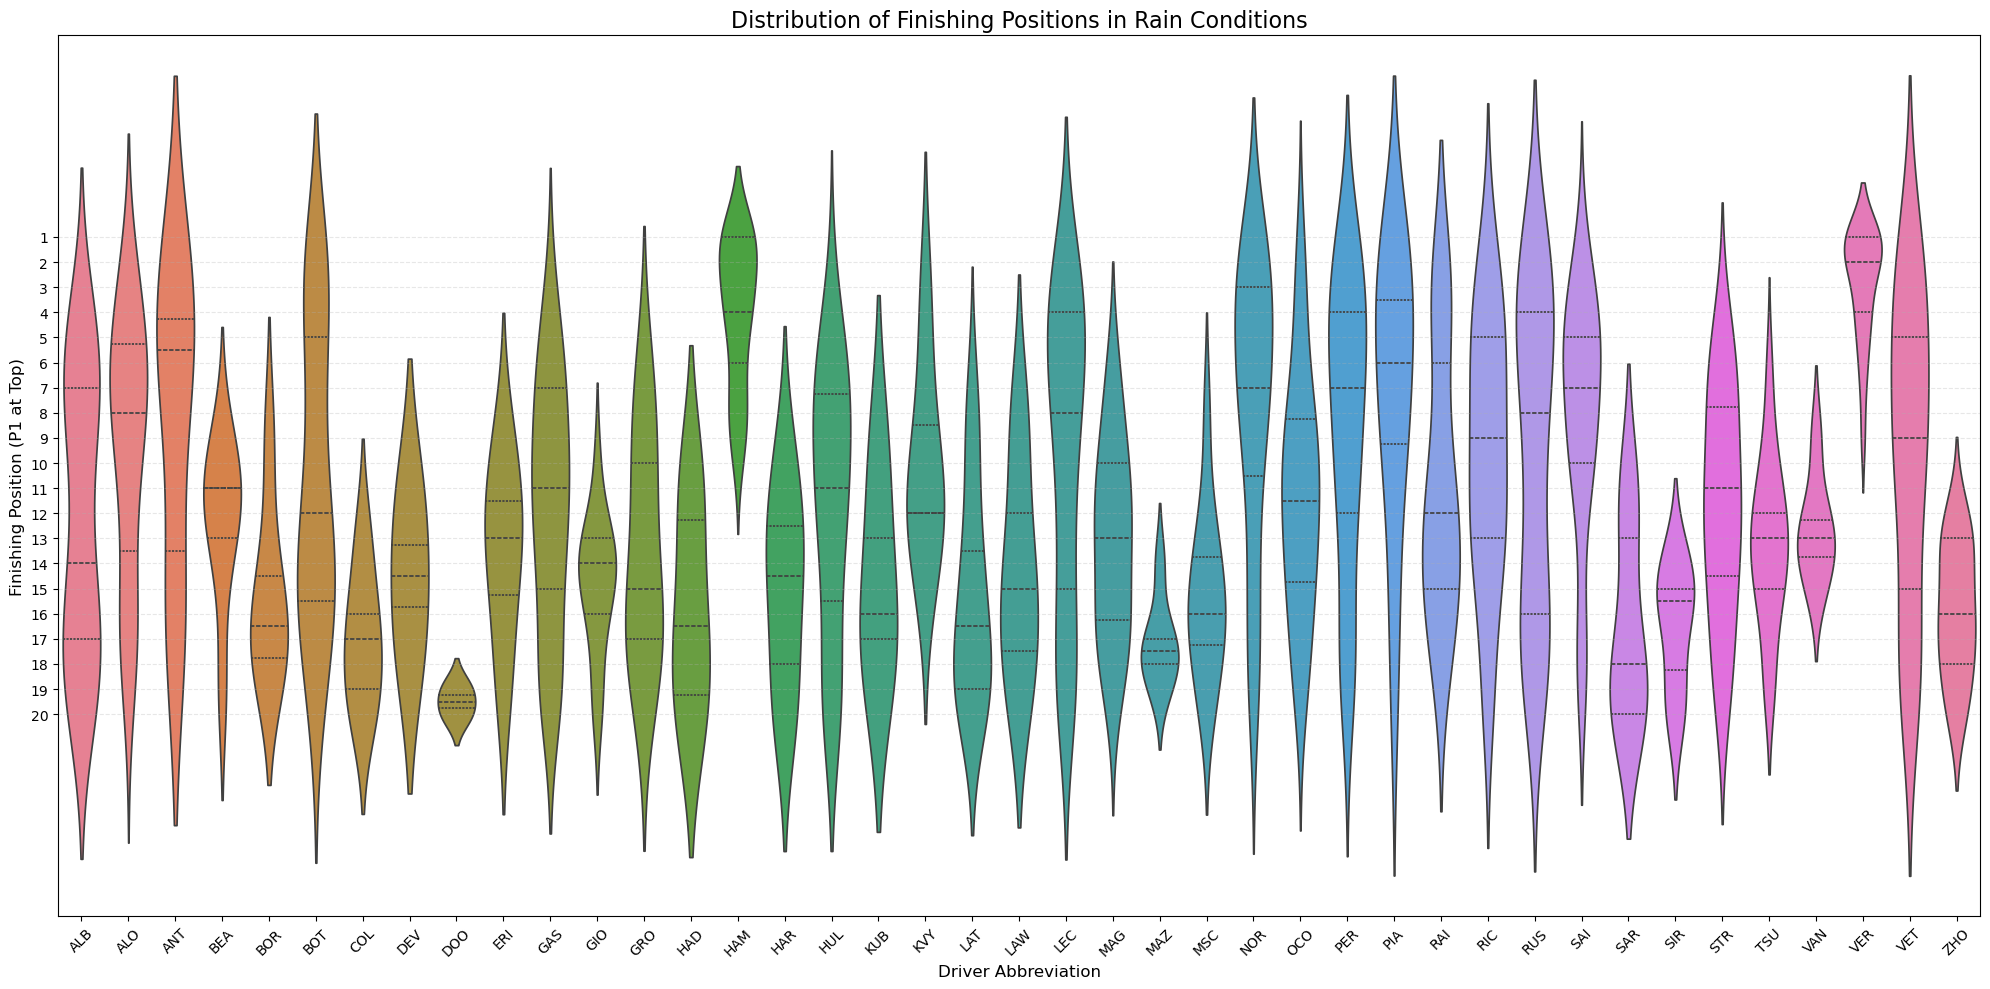

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert the Spark DataFrame to a localized Pandas DataFrame
pandas_results = joined_results.toPandas()

# Step 1.5: Filter the dataset to only include rainy races
# Note: If your column uses 1 instead of True, change this to == 1
pandas_results = pandas_results[pandas_results["rain"] == True]

# Step 2: Clean up positions by converting them to numeric (ignoring string DNFs)
pandas_results["Position"] = pandas_results["Position"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results = pandas_results.dropna(subset=["Position"])

# Step 3: Sort drivers alphabetically for cleaner visual presentation
pandas_results = pandas_results.sort_values("Abbreviation")

# Step 4: Render the chart
plt.figure(figsize=(20, 10))

# Since we are only looking at Rain = True, we remove hue="Abbreviation" 
# and use a single color for a cleaner, unified presentation.
sns.violinplot(
    data=pandas_results, 
    x="Abbreviation", 
    y="Position",
    hue="Abbreviation",  # A nice racing blue for wet conditions
    inner="quart"     # Shows median and quartiles inside the violins
)

plt.title("Distribution of Finishing Positions in Rain Conditions", fontsize=16)
plt.xlabel("Driver Abbreviation", fontsize=12)
plt.ylabel("Finishing Position (P1 at Top)", fontsize=12)

# Invert Y-axis so P1 is at the top of the chart
plt.gca().invert_yaxis()
plt.yticks(range(1, 21)) 

plt.xticks(rotation=45) 
plt.grid(True, axis='y', linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


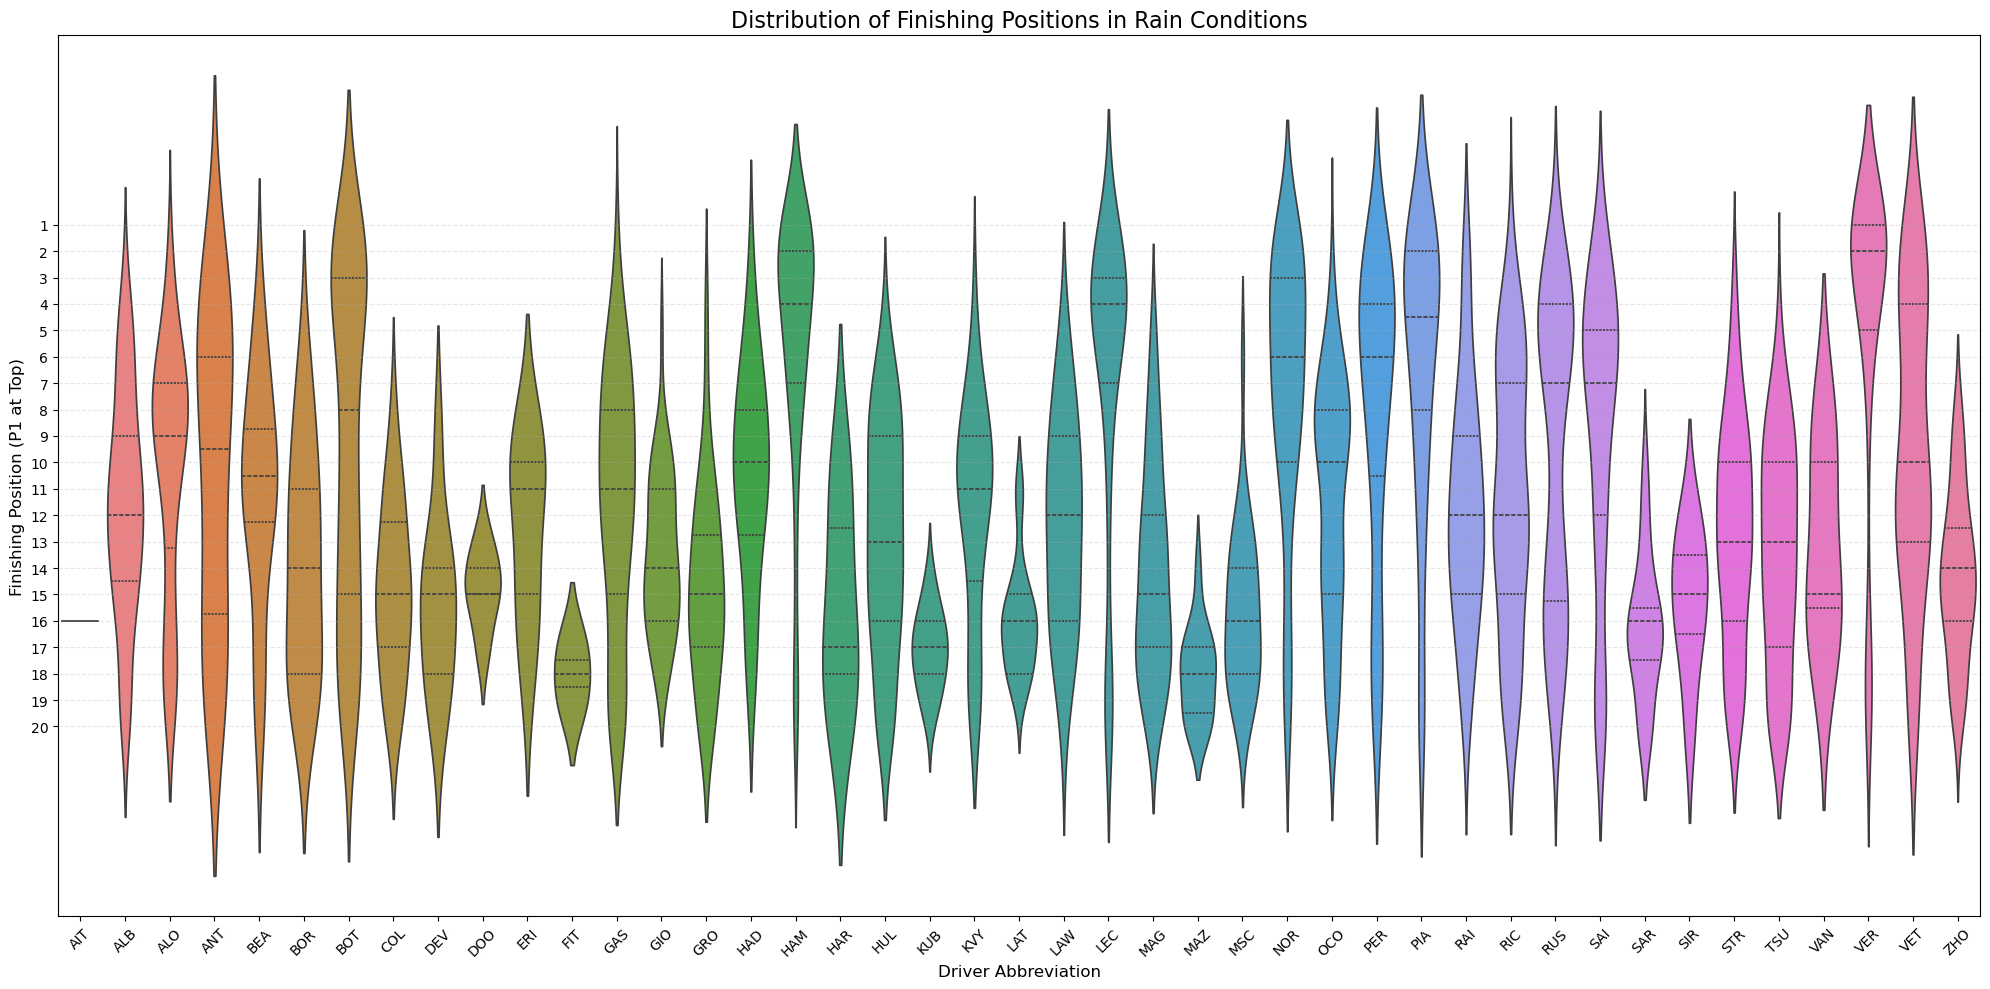

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert the Spark DataFrame to a localized Pandas DataFrame
pandas_results = joined_results.toPandas()

# Step 1.5: Filter the dataset to only include rainy races
# Note: If your column uses 1 instead of True, change this to == 1
pandas_results = pandas_results[pandas_results["rain"] == False]

# Step 2: Clean up positions by converting them to numeric (ignoring string DNFs)
pandas_results["Position"] = pandas_results["Position"].astype(str).str.extract(r'(\d+)').astype(float)
pandas_results = pandas_results.dropna(subset=["Position"])

# Step 3: Sort drivers alphabetically for cleaner visual presentation
pandas_results = pandas_results.sort_values("Abbreviation")

# Step 4: Render the chart
plt.figure(figsize=(20, 10))

# Since we are only looking at Rain = True, we remove hue="Abbreviation" 
# and use a single color for a cleaner, unified presentation.
sns.violinplot(
    data=pandas_results, 
    x="Abbreviation", 
    y="Position",
    hue="Abbreviation",  # A nice racing blue for wet conditions
    inner="quart"     # Shows median and quartiles inside the violins
)

plt.title("Distribution of Finishing Positions in Rain Conditions", fontsize=16)
plt.xlabel("Driver Abbreviation", fontsize=12)
plt.ylabel("Finishing Position (P1 at Top)", fontsize=12)

# Invert Y-axis so P1 is at the top of the chart
plt.gca().invert_yaxis()
plt.yticks(range(1, 21)) 

plt.xticks(rotation=45) 
plt.grid(True, axis='y', linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


Based on the tables above, the weather does not impact the lap times very much. These average lap times do not influence the positions very much either. Rain versus not rain does have some influence on the median results of the finishing positions of each driver. Below we will investigate if it will influence the status.

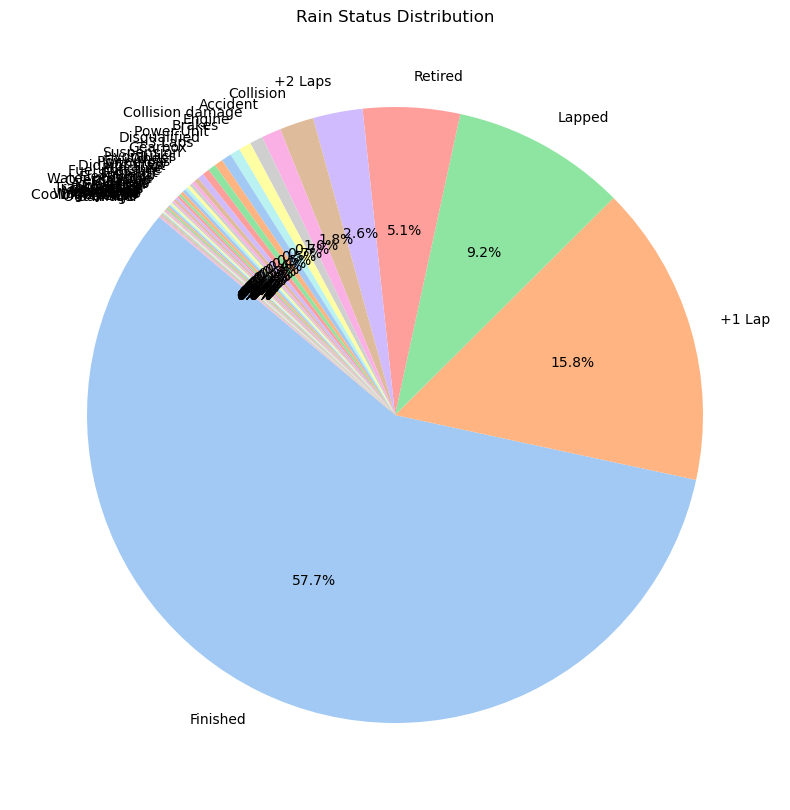

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Convert the Spark DataFrame to a localized Pandas DataFrame
pandas_results = joined_results.toPandas()

# 1. Filter the dataset where the Abbreviation column is exactly "Mercedes"
rain_results = pandas_results[pandas_results['rain'] == False]

# 2. Aggregate the filtered data to get the counts for each status
status_counts = rain_results['Status'].value_counts()

# Set up your figure size
plt.figure(figsize=(10, 10))

# 3. Use Seaborn's color palettes to keep the Seaborn look
colors = sns.color_palette('pastel')[0:len(status_counts)]

# 4. Create the pie chart using Matplotlib
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',  # Displays the percentage on each wedge
    startangle=140,     # Rotates the start of the pie chart for better alignment
    colors=colors
)

# Set the title to reflect the filter
plt.title("Rain Status Distribution")

# Display the chart
plt.show()


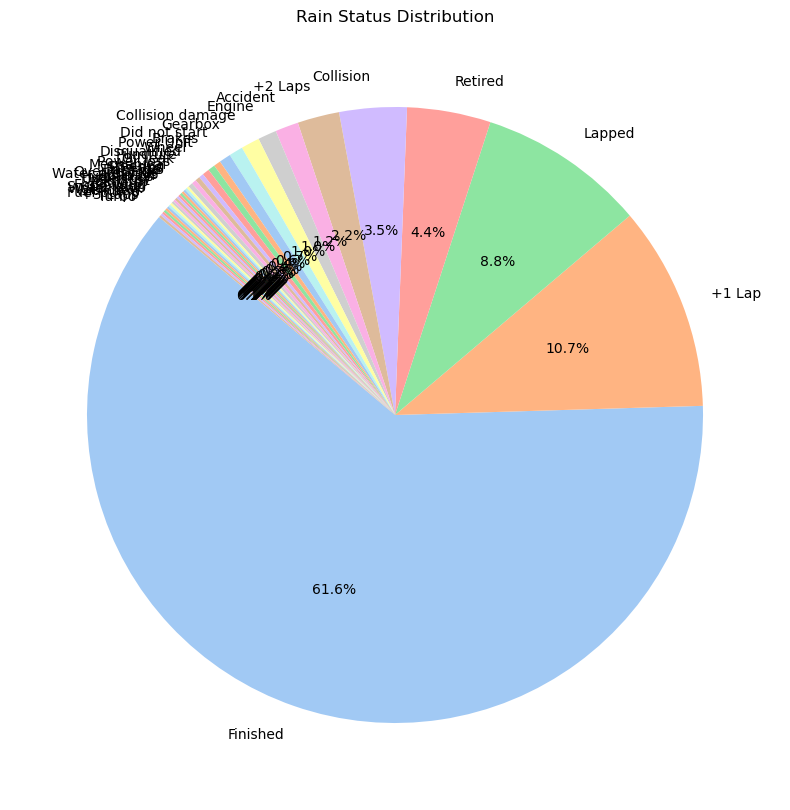

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Convert the Spark DataFrame to a localized Pandas DataFrame
pandas_results = joined_results.toPandas()

# 1. Filter the dataset where the Abbreviation column is exactly "Mercedes"
rain_results = pandas_results[pandas_results['rain'] == True]

# 2. Aggregate the filtered data to get the counts for each status
status_counts = rain_results['Status'].value_counts()

# Set up your figure size
plt.figure(figsize=(10, 10))

# 3. Use Seaborn's color palettes to keep the Seaborn look
colors = sns.color_palette('pastel')[0:len(status_counts)]

# 4. Create the pie chart using Matplotlib
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',  # Displays the percentage on each wedge
    startangle=140,     # Rotates the start of the pie chart for better alignment
    colors=colors
)

# Set the title to reflect the filter
plt.title("Rain Status Distribution")

# Display the chart
plt.show()


There is a slightly higher percentage of Finished results when it does rain compared to when it does not rain in the race. Because of this I would include if it rained in the predictors. 

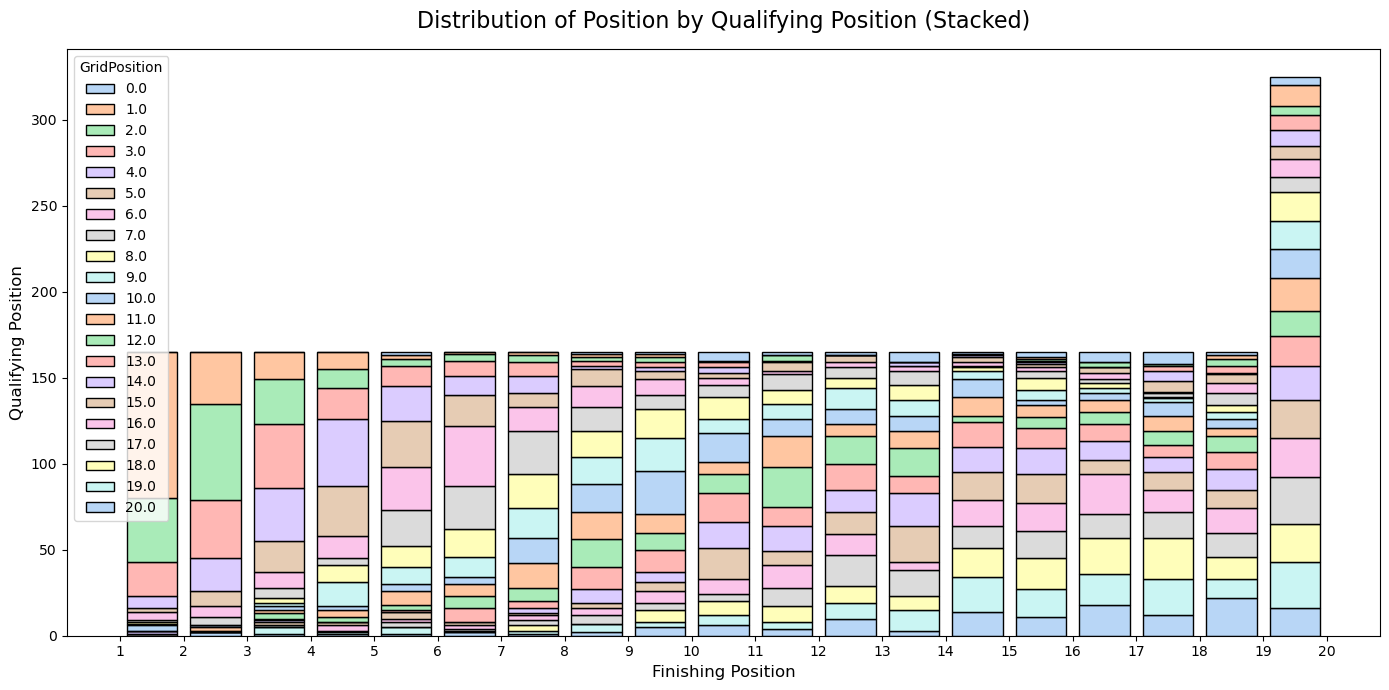

In [28]:
# Check the distribution of classified position to position #check qualifying to finish position
# check the distribution of status by location
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a wide figure size so your locations fit nicely
plt.figure(figsize=(14, 7))

# Create the stacked bar chart using histplot
sns.histplot(
    x="Position", 
    hue="GridPosition", 
    data=pandas_results, 
    multiple="stack",   # This forces the categories to stack instead of grouping side-by-side
    palette="pastel",   # Uses Seaborn's modern, soft coloring scheme
    shrink=0.8,          # Creates clean gaps between each location bar
    binwidth=1 
)

# Style your labels, title, and layout
plt.title("Distribution of Position by Qualifying Position (Stacked)", fontsize=16, pad=15)
plt.xlabel("Finishing Position", fontsize=12)
plt.ylabel("Qualifying Position", fontsize=12)

# Rotate the location labels on the X-axis so they don't overlap each other
max_x = int(pandas_results['Position'].max())
plt.xticks(range(1, max_x + 1, 1))

# Automatically prevents edge cutting and displays the chart
plt.tight_layout()
plt.show()




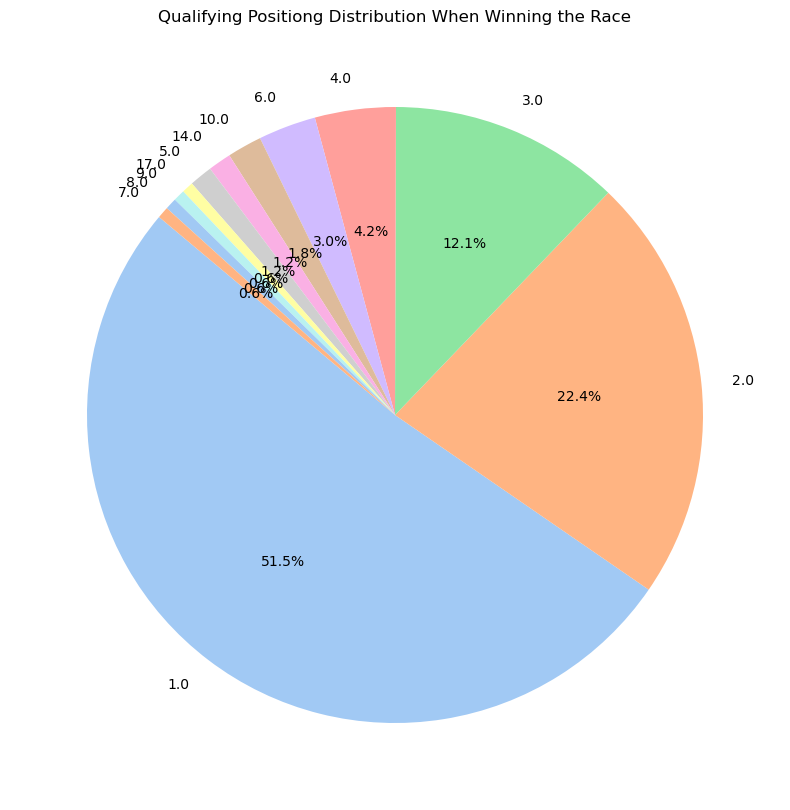

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Convert the Spark DataFrame to a localized Pandas DataFrame
pandas_results = joined_results.toPandas()

# 1. Filter the dataset where the Finishing Position equals 1 
first_results = pandas_results[pandas_results['Position'] == 1]

# 2. Aggregate the filtered data to get the counts for each status
status_counts = first_results['GridPosition'].value_counts()

# Set up your figure size
plt.figure(figsize=(10, 10))

# 3. Use Seaborn's color palettes to keep the Seaborn look
colors = sns.color_palette('pastel')[0:len(status_counts)]

# 4. Create the pie chart using Matplotlib
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',  # Displays the percentage on each wedge
    startangle=140,     # Rotates the start of the pie chart for better alignment
    colors=colors
)

# Set the title to reflect the filter
plt.title("Qualifying Positiong Distribution When Winning the Race")

# Display the chart
plt.show()


When you qualify in first, there historically is about a 51.5% conversion rate. This indicates that you would want to include Grid Position(Qualifying Position) as a predictor.